Pulse Amplitude Modulation (PAM) is a technique where:

The amplitude of regularly spaced pulses is varied according to the instantaneous value of the message signal.

💡 Simple Idea:
You have a continuous signal (like voice)
You sample it at regular intervals
At each sample → create a pulse with that amplitude

👉 So instead of continuous signal → you send discrete pulses carrying amplitude info

🎯 Why PAM is Used?
First step in converting analog → digital
Used in:
PCM (Pulse Code Modulation)
TDM systems
Digital communication systems
🔷 2. Core Concept (How PAM Works)
📊 Step-by-step process:

Start with message signal:

𝑚(𝑡)
=
𝐴
𝑚
sin
⁡
(
2
𝜋
𝑓
𝑚
𝑡
)
m(t)=A
m
	​

sin(2πf
m
	​

t)
Generate sampling signal:
A high-frequency pulse train

Multiply:

𝑠
(
𝑡
)
=
𝑚
(
𝑡
)
×
𝑝
(
𝑡
)
s(t)=m(t)×p(t)

👉 This multiplication produces PAM signal

⚠️ Important Condition (Very Important for Viva)
📌 Nyquist Theorem:
𝑓
𝑠
≥
2
𝑓
𝑚
f
s
	​

≥2f
m
	​

Your code:
𝑓
𝑚
=
5
f
m
	​

=5
𝑓
𝑠
=
20
f
s
	​

=20

✅ Condition satisfied → No aliasing

📡 Types of PAM (You might be asked)
Natural PAM
Flat-top PAM

👉 Your code simulates Natural PAM (approx.)

🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Analog Signal → SAMPLING (PAM) → Quantization → Encoding → Transmission
🔥 Key Point:
PAM is part of Baseband Signal Processing
It happens at the transmitter side

👉 It is the FIRST STEP toward digital communication

🧠 Classification:
Concept	Type
PAM	Analog Pulse Modulation
Stage	Before digitization
Domain	Time-domain sampling
🔷 4. Code Explanation (Line by Line)

Now let’s connect theory with your code 👇

⏱️ Time Axis
t = np.linspace(0, 1, 1000)
Creates time from 0 to 1 sec
1000 samples → smooth signal
🎵 Message Signal
fm = 5
Am = 1
message = Am * np.sin(2 * np.pi * fm * t)

👉 This is:

𝑚
(
𝑡
)
=
sin
⁡
(
2
𝜋
⋅
5
𝑡
)
m(t)=sin(2π⋅5t)
Analog signal (low frequency)
Represents voice/data
⚡ Sampling Signal
fs = 20
sampling = np.sin(2 * np.pi * fs * t)
sampling = (sampling > 0).astype(int)
What’s happening?
Create sine wave (high frequency)
Convert it into pulses:

👉 (sampling > 0):

Positive → 1
Negative → 0

👉 So you get:

Pulse Train (0s and 1s)
🔁 PAM Signal
pam = message * sampling

👉 This is the KEY LINE

𝑠
(
𝑡
)
=
𝑚
(
𝑡
)
×
𝑝
(
𝑡
)
s(t)=m(t)×p(t)
When pulse = 1 → message passes
When pulse = 0 → signal blocked

👉 Result = sampled signal = PAM

📊 Plotting
Message Signal
plt.subplot(3,1,1)
plt.plot(t, message)

👉 Continuous sine wave

Sampling Signal
plt.subplot(3,1,2)
plt.plot(t, sampling)

👉 Pulse train (square-like)

PAM Signal
plt.subplot(3,1,3)
plt.plot(t, pam)

👉 Pulses whose height follows message

🔷 5. Output Understanding

You will see:

Top Graph → Smooth sine wave
Middle Graph → Pulses (0 and 1)
Bottom Graph → Sampled signal

👉 Bottom graph is your PAM signal

🔷 6. Viva / Exam Questions (Very Important)
❓ What is PAM?

Pulse Amplitude Modulation is a technique where the amplitude of pulses varies according to the message signal.

❓ Why sampling is needed?

To convert continuous signal into discrete form for digital processing.

❓ What happens if 
𝑓
𝑠
<
2
𝑓
𝑚
f
s
	​

<2f
m
	​

?

👉 Aliasing occurs (signal distortion)

❓ Why multiplication is used?

To sample the signal using pulse train.

❓ Difference between PAM and ASK?
PAM → amplitude follows analog signal
ASK → amplitude represents binary data
❓ Is PAM analog or digital?

👉 It is analog pulse modulation, not fully digital.

🔥 Final Intuition (Very Important)

Think like this:

👉 Message = smooth music
👉 Sampling = turning ON/OFF switch
👉 PAM = taking snapshots of music at intervals

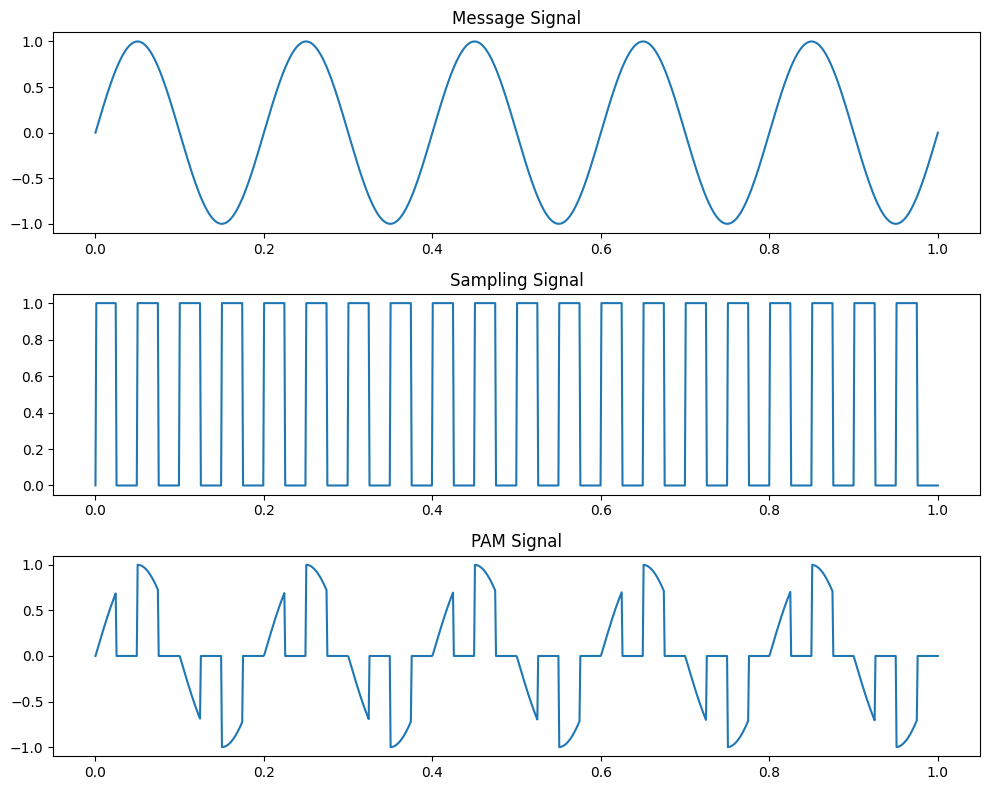

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
t = np.linspace(0, 1, 1000)

# Message signal parameters
fm = 5   # message frequency
Am = 1   # amplitude

# Message signal
message = Am * np.sin(2 * np.pi * fm * t)

# Sampling signal (pulse train)
fs = 20  # sampling frequency
sampling = np.sin(2 * np.pi * fs * t)
sampling = (sampling > 0).astype(int)  # convert to pulses

# PAM signal
pam = message * sampling

# Plotting
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, message)
plt.title("Message Signal")

plt.subplot(3,1,2)
plt.plot(t, sampling)
plt.title("Sampling Signal")

plt.subplot(3,1,3)
plt.plot(t, pam)
plt.title("PAM Signal")

plt.tight_layout()
plt.show()

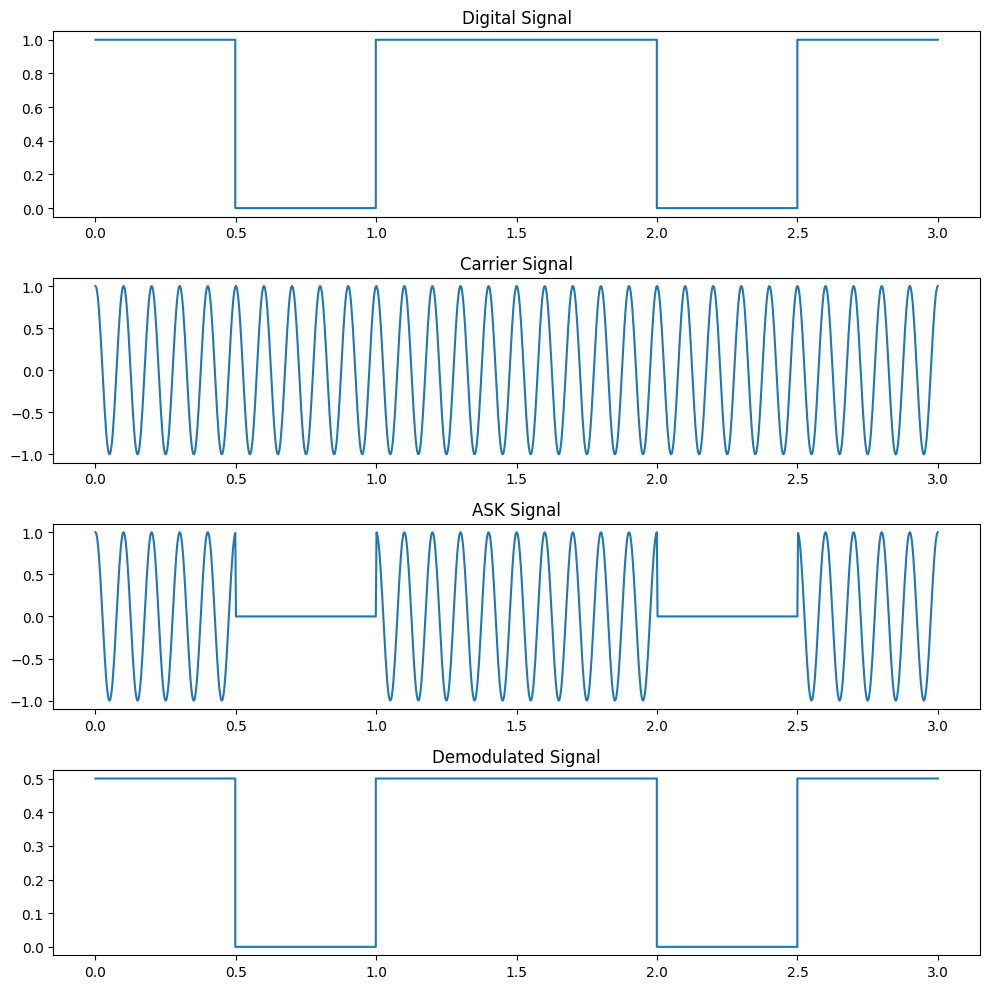

Original bits:   [1 0 1 1 0 1]
Recovered bits:  [1, 0, 1, 1, 0, 1]


In [25]:
# ask with demodulation
import numpy as np
import matplotlib.pyplot as plt

# Parameters
bit_rate = 2
fc = 10
data = np.array([1, 0, 1, 1, 0, 1])

Tb = 1 / bit_rate
samples_per_bit = 200

t = np.linspace(0, Tb * len(data), samples_per_bit * len(data))

digital_signal = np.repeat(data, samples_per_bit)

carrier = np.cos(2 * np.pi * fc * t)

# ASK modulation
ask_signal = digital_signal * carrier

# ---------------- DEMODULATION ----------------
# Step 1: Multiply with carrier
demodulated = ask_signal * carrier

# Step 2: Integrate (average) over each bit period
recovered_bits = []
demod_signal_smooth = np.zeros_like(demodulated)

for i in range(len(data)):
    start = i * samples_per_bit
    end = (i + 1) * samples_per_bit
    
    segment = demodulated[start:end]
    avg = np.mean(segment)
    
    recovered_bits.append(1 if avg > 0.25 else 0)  # threshold
    
    # store smoothed signal for plotting
    demod_signal_smooth[start:end] = avg

# ---------------- PLOTTING ----------------
plt.figure(figsize=(10,10))

plt.subplot(4,1,1)
plt.step(t, digital_signal)
plt.title("Digital Signal")

plt.subplot(4,1,2)
plt.plot(t, carrier)
plt.title("Carrier Signal")

plt.subplot(4,1,3)
plt.plot(t, ask_signal)
plt.title("ASK Signal")

plt.subplot(4,1,4)
plt.step(t, demod_signal_smooth)
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

print("Original bits:  ", data)
print("Recovered bits: ", recovered_bits)

Amplitude Shift Keying (ASK) is a digital modulation technique where:

The amplitude of a carrier signal is varied according to binary data (0 and 1).

💡 Simple Idea:
You have binary data → 101010...
You send:
High amplitude → for bit 1
Low (or zero) amplitude → for bit 0

👉 So, information is carried by amplitude changes of a carrier wave

🎯 Why ASK is Used?
Simple and easy to implement
Used in:
Optical communication
RFID systems
Early wireless communication
🔷 2. Core Concept
📊 Mathematical Representation:
𝑠
(
𝑡
)
=
{
𝐴
1
cos
⁡
(
2
𝜋
𝑓
𝑡
)
,
	
for bit 1


𝐴
2
cos
⁡
(
2
𝜋
𝑓
𝑡
)
,
	
for bit 0
s(t)={
A
1
	​

cos(2πft),
A
2
	​

cos(2πft),
	​

for bit 1
for bit 0
	​


👉 In your code:

𝐴
1
=
10
A
1
	​

=10
𝐴
2
=
5
A
2
	​

=5
📡 How ASK Works (Step-by-step):
Binary input → 1 0 1 0 ...
Generate carrier signal
Change amplitude based on bit:
1 → strong signal
0 → weak signal
Transmit through channel
Receiver detects amplitude → recovers bits
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → ASK Modulation → Channel → ASK Demodulation → Output Data
🧠 Classification:
Concept	Type
ASK	Digital Modulation
Carrier	Analog
Data	Digital
Stage	Passband transmission
🔥 Key Difference from PAM:
PAM	ASK
Analog signal sampled	Digital bits transmitted
Baseband	Passband
No carrier needed	Carrier required
🔷 4. Code Explanation (Line by Line)
🔢 Input Data
x = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1])

👉 Binary data sequence

⏱️ Bit Duration & Sampling
bp = 1e-6
samples_per_bit = 100
Each bit duration = 1 microsecond
100 samples per bit → smooth waveform
📊 Digital Signal
bit = np.repeat(x, samples_per_bit)
t1 = np.linspace(0, bp * len(x), len(bit))

👉 Converts bits into a continuous digital waveform

📡 ASK Parameters
A1, A2 = 10, 5
br = 1 / bp
f = br * 10
𝐴
1
=
10
A
1
	​

=10 → amplitude for bit 1
𝐴
2
=
5
A
2
	​

=5 → amplitude for bit 0
Carrier frequency 
𝑓
f is much higher than bit rate
⏳ Time for One Bit
t2 = np.linspace(0, bp, 100)

👉 Time axis for one bit duration

🔁 ASK Modulation
m = []
for bit_val in x:
    if bit_val == 1:
        y = A1 * np.cos(2 * np.pi * f * t2)
    else:
        y = A2 * np.cos(2 * np.pi * f * t2)
    m.extend(y)

👉 Key idea:

For each bit:
Generate a cosine wave
Change amplitude based on bit

✔ This creates ASK signal

📡 Final Modulated Signal
m = np.array(m)
t3 = np.linspace(0, bp * len(x), len(m))
🔷 5. ASK Demodulation (Very Important)
🧠 Concept:
Multiply received signal with carrier
Integrate over bit duration
Compare with threshold
🔍 Code:
z = np.trapezoid(segment * carrier, t2)

👉 This performs:

∫
𝑠
(
𝑡
)
cos
⁡
(
2
𝜋
𝑓
𝑡
)
𝑑
𝑡
∫s(t)cos(2πft)dt

✔ Extracts amplitude information

🎯 Decision Making
if (2 * z / bp) > 7.5:
    mn.append(1)
else:
    mn.append(0)
Threshold = 7.5 (between 10 and 5)

👉 If strong → 1
👉 If weak → 0

🔁 Reconstructed Signal
bit_rec = np.repeat(mn, samples_per_bit)

👉 Converts recovered bits into waveform

🔷 6. Output Understanding

You will see:

1️⃣ Digital Signal
Square wave (input bits)
2️⃣ ASK Signal
Carrier wave
Amplitude changes based on bits
3️⃣ Recovered Signal
Should match original bits
🔷 7. Viva / Exam Questions
❓ What is ASK?

ASK is a digital modulation technique where carrier amplitude varies according to binary data.

❓ Why carrier is used?

To transmit signal over long distances (passband transmission).

❓ What is threshold detection?

A method to decide whether received signal is 0 or 1 based on amplitude.

❓ What happens in noisy channel?

ASK is very sensitive to noise (important point!)

❓ Difference between ASK and FSK?
ASK → amplitude changes
FSK → frequency changes
🔥 Final Intuition

Think like this:

👉 Carrier = continuous wave
👉 Bits = instructions
👉 ASK = “turn volume HIGH or LOW depending on bit”

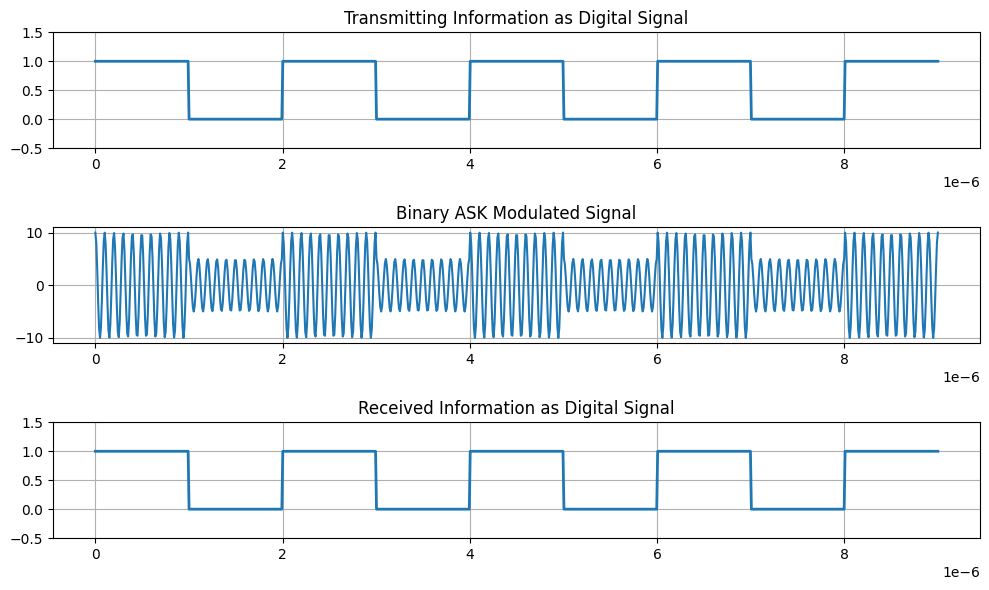

In [ ]:
#ask sir
import numpy as np
import matplotlib.pyplot as plt

# Input data
x = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1])

# Parameters
bp = 1e-6
samples_per_bit = 100

# Digital signal
bit = np.repeat(x, samples_per_bit)
t1 = np.linspace(0, bp * len(x), len(bit))

# ASK parameters
A1, A2 = 10, 5
br = 1 / bp
f = br * 10

# Time for one bit
t2 = np.linspace(0, bp, 100)

# ASK Modulation
m = []
for bit_val in x:
    if bit_val == 1:
        y = A1 * np.cos(2 * np.pi * f * t2)
    else:
        y = A2 * np.cos(2 * np.pi * f * t2)
    m.extend(y)

m = np.array(m)
t3 = np.linspace(0, bp * len(x), len(m))

# ASK Demodulation
mn = []
for i in range(0, len(m), len(t2)):
    segment = m[i:i + len(t2)]
    carrier = np.cos(2 * np.pi * f * t2)

    z = np.trapezoid(segment * carrier, t2)

    if (2 * z / bp) > 7.5:
        mn.append(1)
    else:
        mn.append(0)

mn = np.array(mn)

# Recovered digital signal
bit_rec = np.repeat(mn, samples_per_bit)
t4 = np.linspace(0, bp * len(mn), len(bit_rec))

# Plotting
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t1, bit, linewidth=2)
plt.title("Transmitting Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t3, m)
plt.title("Binary ASK Modulated Signal")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t4, bit_rec, linewidth=2)
plt.title("Received Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.tight_layout()
plt.show()

Phase Shift Keying (PSK) is a digital modulation technique where:

The phase of a carrier signal is changed according to binary data, while amplitude and frequency remain constant.

💡 Simple Idea:
Bit 1 → normal carrier
Bit 0 → phase inverted (180° shift)

👉 So instead of changing amplitude (ASK), we flip the wave

🎯 Why PSK is Used?
Much more robust against noise than ASK
Widely used in:
Wi-Fi
Bluetooth
Satellite communication
🔷 2. Core Concept
📊 Mathematical Representation (BPSK):
𝑠
(
𝑡
)
=
{
𝐴
cos
⁡
(
2
𝜋
𝑓
𝑡
)
,
	
bit = 1


−
𝐴
cos
⁡
(
2
𝜋
𝑓
𝑡
)
,
	
bit = 0
s(t)={
Acos(2πft),
−Acos(2πft),
	​

bit = 1
bit = 0
	​


👉 Same as:

Bit 0 → phase shift = 180°
🔁 Key Idea:

Instead of:

Changing amplitude (ASK ❌)

We do:

Multiply by +1 or -1 (PSK ✅)
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → PSK Modulation → Channel → PSK Demodulation → Output
🧠 Classification:
Concept	Type
PSK	Digital Modulation
Signal	Passband
Carrier	Constant amplitude
Info carried in	Phase
🔥 Comparison (Very Important)
Feature	ASK	PSK
Parameter changed	Amplitude	Phase
Noise resistance	Low ❌	High ✅
Power efficiency	Low	High
🔷 4. Code Explanation (Line by Line)
🔢 Input Data
data = np.array([1, 0, 1, 1, 0, 1])

👉 Binary sequence

⏱️ Parameters
bit_rate = 2
Tb = 1 / bit_rate
samples_per_bit = 200
fc = 10
Bit duration 
𝑇
𝑏
T
b
	​

Carrier frequency 
𝑓
𝑐
f
c
	​

High samples → smooth waveform
⏳ Time Vector
t = np.linspace(0, Tb * len(data), samples_per_bit * len(data))

👉 Time for full signal

📊 Digital Signal
digital_signal = np.repeat(data, samples_per_bit)

👉 Converts bits into step waveform

📡 Carrier Signal
carrier = np.cos(2 * np.pi * fc * t)

👉 Base cosine wave

🔷 🔁 BPSK MODULATION (Most Important Part)
polar_data = 2 * digital_signal - 1
🔥 Why this line?
Converts:
1 → +1
0 → -1

👉 This is polar encoding

psk_signal = polar_data * carrier

👉 This is the KEY:

𝑠
(
𝑡
)
=
±
cos
⁡
(
2
𝜋
𝑓
𝑡
)
s(t)=±cos(2πft)
+1 → normal wave
-1 → inverted wave (180° shift)
🔷 5. Demodulation (Very Important)
🧠 Concept:
Multiply received signal with carrier
Average over bit duration
Detect sign
🔍 Code:
demodulated = psk_signal * carrier

👉 Coherent detection (mixing)

🔁 Bit Recovery
avg = np.mean(segment)

👉 If:

avg > 0 → bit = 1
avg < 0 → bit = 0
Decision:
recovered_bits.append(1 if avg > 0 else 0)
🔁 Reconstructed Signal
recovered_signal = np.repeat(recovered_bits, samples_per_bit)
🔷 6. Output Understanding

You will see:

1️⃣ Digital Signal
Step waveform (input bits)
2️⃣ PSK Signal
Same amplitude always
But phase flips for 0

👉 Looks like waveform suddenly inverts

3️⃣ Recovered Signal
Should match original
🔷 7. Viva / Exam Questions
❓ What is PSK?

PSK is a digital modulation technique where the phase of a carrier is varied according to input data.

❓ What is BPSK?

Binary PSK uses two phases:

0° → bit 1
180° → bit 0
❓ Why PSK is better than ASK?
Less affected by noise
Constant amplitude → power efficient
❓ What is coherent detection?

Using a synchronized carrier at receiver.

❓ Why multiply by carrier in demodulation?

To extract phase information.

🔥 Final Intuition (Very Important)

Think like this:

👉 Carrier = wave moving forward
👉 Bit 1 → keep direction
👉 Bit 0 → flip direction

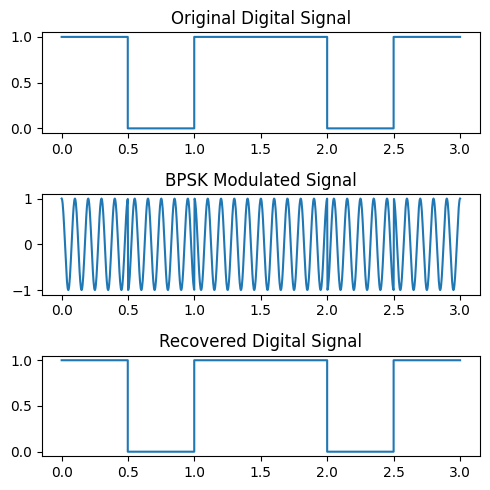

Original bits:   [1 0 1 1 0 1]
Recovered bits:  [1, 0, 1, 1, 0, 1]


In [ ]:
#l3 bpsk
import numpy as np
import matplotlib.pyplot as plt

# Input data
data = np.array([1, 0, 1, 1, 0, 1])

# Parameters
bit_rate = 2
Tb = 1 / bit_rate
samples_per_bit = 200
fc = 10

# Time vector
t = np.linspace(0, Tb * len(data), samples_per_bit * len(data))

# Digital signal
digital_signal = np.repeat(data, samples_per_bit)

# Carrier
carrier = np.cos(2 * np.pi * fc * t)

# ---------------- BPSK MODULATION ----------------
# 1 -> +1, 0 -> -1
polar_data = 2 * digital_signal - 1
psk_signal = polar_data * carrier

# ---------------- DEMODULATION ----------------
# Multiply with carrier
demodulated = psk_signal * carrier

# Recover bits using integration (averaging)
recovered_bits = []
demod_signal_smooth = np.zeros_like(demodulated)

for i in range(len(data)):
    start = i * samples_per_bit
    end = (i + 1) * samples_per_bit
    
    segment = demodulated[start:end]
    avg = np.mean(segment)
    
    recovered_bits.append(1 if avg > 0 else 0)

# Reconstructed digital signal
recovered_signal = np.repeat(recovered_bits, samples_per_bit)

# ---------------- PLOTTING ----------------
plt.figure(figsize=(5,5))

plt.subplot(3,1,1)
plt.step(t, digital_signal)
plt.title("Original Digital Signal")

plt.subplot(3,1,2)
plt.plot(t, psk_signal)
plt.title("BPSK Modulated Signal")


plt.subplot(3,1,3)
plt.step(t, recovered_signal)
plt.title("Recovered Digital Signal")

plt.tight_layout()
plt.show()

# Output
print("Original bits:  ", data)
print("Recovered bits: ", recovered_bits)

Frequency Shift Keying (FSK) is a digital modulation technique where:

The frequency of the carrier signal is changed according to binary data, while amplitude remains constant.

💡 Simple Idea:
Bit 1 → High frequency
Bit 0 → Low frequency

👉 So instead of:

Amplitude change (ASK ❌)
Phase change (PSK ❌)

We do:

Frequency change (FSK ✅)
🎯 Why FSK is Used?
More robust than ASK
Easier to implement than PSK (in some systems)
Used in:
Bluetooth (early versions)
Modems
Radio communication
🔷 2. Core Concept
📊 Mathematical Representation:
𝑠
(
𝑡
)
=
{
𝐴
cos
⁡
(
2
𝜋
𝑓
1
𝑡
)
,
	
bit = 1


𝐴
cos
⁡
(
2
𝜋
𝑓
0
𝑡
)
,
	
bit = 0
s(t)={
Acos(2πf
1
	​

t),
Acos(2πf
0
	​

t),
	​

bit = 1
bit = 0
	​


👉 In your code:

𝑓
1
=
20
f
1
	​

=20 (bit 1)
𝑓
0
=
5
f
0
	​

=5 (bit 0)
🔁 Key Idea:
Same amplitude
Same phase (generally)
Only frequency changes
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → FSK Modulation → Channel → FSK Demodulation → Output
🧠 Classification:
Concept	Type
FSK	Digital Modulation
Signal	Passband
Carrier	Constant amplitude
Info carried in	Frequency
🔥 Quick Comparison (Very Important)
Feature	ASK	PSK	FSK
Changes	Amplitude	Phase	Frequency
Noise immunity	Low ❌	High ✅	Medium ✅
Complexity	Low	Medium	Medium
🔷 4. Code Explanation (Line by Line)
⏱️ Parameters & Time
bit_rate = 2
t_total = 1
t = np.linspace(0, t_total, 1000)
Total time = 1 sec
Time resolution = 1000 samples
📡 Frequencies
f1 = 20   # for bit 1
f0 = 5    # for bit 0

👉 Core of FSK:

High freq → 1
Low freq → 0
🔢 Binary Data
data = np.array([1, 0, 1, 1, 0, 1])
bit_samples = len(t) // len(data)

👉 Divides total signal into equal parts per bit

🔷 🔁 FSK MODULATION
fsk_signal = np.zeros_like(t)

👉 Initialize output signal

for i, bit in enumerate(data):
    start = i * bit_samples
    end = start + bit_samples

👉 Split signal into bit intervals

if bit == 1:
    fsk_signal[start:end] = np.cos(2 * np.pi * f1 * t[start:end])
else:
    fsk_signal[start:end] = np.cos(2 * np.pi * f0 * t[start:end])

👉 Key idea:

Bit 1 → high frequency wave
Bit 0 → low frequency wave

✔ This creates FSK signal

🔷 5. Demodulation (Very Important)
🧠 Concept:
Compare received signal with both possible frequencies
Choose the one that matches more

👉 This is called correlation detection

🔍 Code:
ref1 = np.cos(2 * np.pi * f1 * t[start:end])
ref0 = np.cos(2 * np.pi * f0 * t[start:end])

👉 Reference signals

corr1 = np.sum(segment * ref1)
corr0 = np.sum(segment * ref0)

👉 Measure similarity:

Higher value → better match
🎯 Decision
if corr1 > corr0:
    demodulated.append(1)
else:
    demodulated.append(0)

👉 Choose frequency → determine bit

🔁 Reconstructed Signal
demod_signal = np.repeat(demodulated, bit_samples)
🔷 6. Output Understanding
1️⃣ Digital Signal
Step waveform (input)
2️⃣ FSK Signal
Frequency changes:
Fast oscillation → bit 1
Slow oscillation → bit 0
3️⃣ Demodulated Signal
Should match original bits
🔷 7. Viva / Exam Questions
❓ What is FSK?

FSK is a digital modulation technique where frequency of carrier varies according to input data.

❓ Why two frequencies are used?

To represent binary 0 and 1.

❓ What is correlation detection?

Comparing received signal with reference signals.

❓ Which is better: PSK or FSK?

👉 PSK is generally better in terms of bandwidth efficiency.

❓ Advantage of FSK over ASK?

👉 Better noise immunity.

🔥 Final Intuition (Very Important)

Think like this:

👉 Bit 1 → fast vibration
👉 Bit 0 → slow vibration

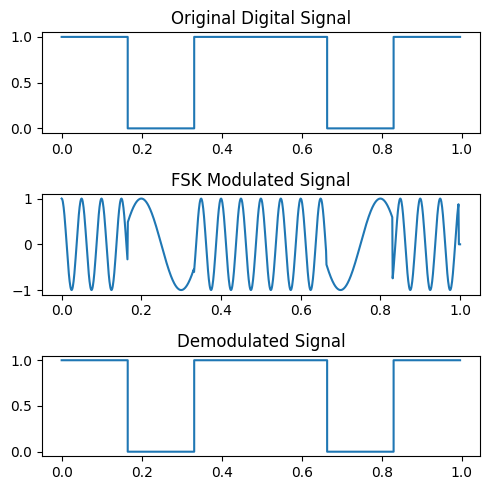

Original Data:      [1 0 1 1 0 1]
Demodulated Data:   [1, 0, 1, 1, 0, 1]


In [8]:
#l4
import numpy as np
import matplotlib.pyplot as plt

# Parameters
bit_rate = 2
t_total = 1
t = np.linspace(0, t_total, 1000)

# Frequencies
f1 = 20   # for bit 1
f0 = 5    # for bit 0

# Binary data
data = np.array([1, 0, 1, 1, 0, 1])
bit_samples = len(t) // len(data)

# Generate FSK signal
fsk_signal = np.zeros_like(t)

for i, bit in enumerate(data):
    start = i * bit_samples
    end = start + bit_samples
    if bit == 1:
        fsk_signal[start:end] = np.cos(2 * np.pi * f1 * t[start:end])
    else:
        fsk_signal[start:end] = np.cos(2 * np.pi * f0 * t[start:end])

# ----------- DEMODULATION -----------
demodulated = []

for i in range(len(data)):
    start = i * bit_samples
    end = start + bit_samples

    segment = fsk_signal[start:end]

    # Correlate with both frequencies
    ref1 = np.cos(2 * np.pi * f1 * t[start:end])
    ref0 = np.cos(2 * np.pi * f0 * t[start:end])

    corr1 = np.sum(segment * ref1)
    corr0 = np.sum(segment * ref0)

    if corr1 > corr0:
        demodulated.append(1)
    else:
        demodulated.append(0)

# Convert to signal form
demod_signal = np.repeat(demodulated, bit_samples)

# Plotting
plt.figure(figsize=(5,5))

plt.subplot(3,1,1)
plt.step(t[:len(np.repeat(data, bit_samples))], np.repeat(data, bit_samples))
plt.title("Original Digital Signal")

plt.subplot(3,1,2)
plt.plot(t, fsk_signal)
plt.title("FSK Modulated Signal")

plt.subplot(3,1,3)
plt.step(t[:len(demod_signal)], demod_signal)
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

print("Original Data:     ", data)
print("Demodulated Data:  ", demodulated)

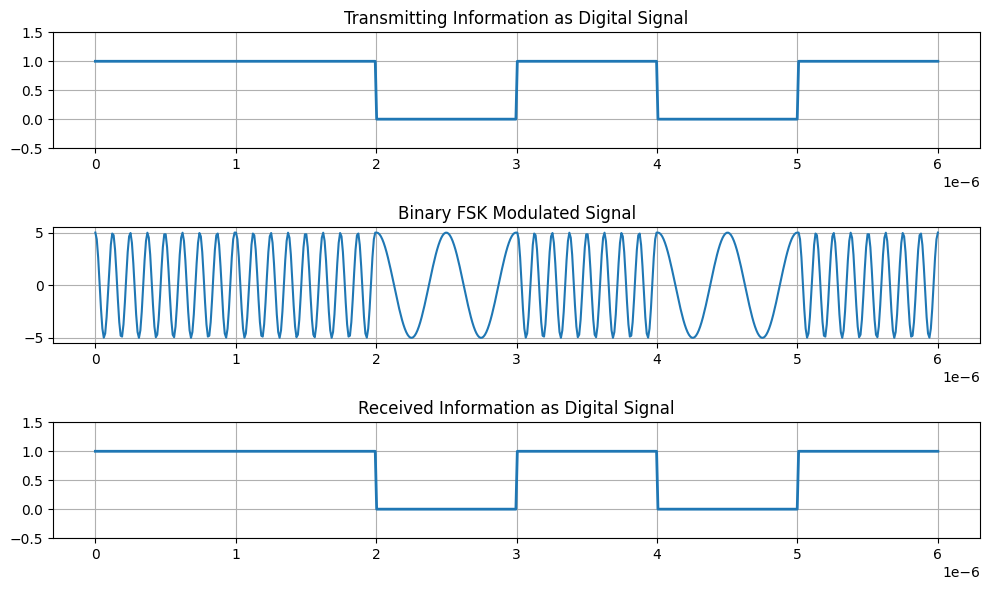

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
x = np.array([1, 1, 0, 1, 0, 1])

# Parameters
bp = 1e-6
samples_per_bit = 100
A = 5

# Time for digital signal
bit = np.repeat(x, samples_per_bit)
t1 = np.linspace(0, bp * len(x), len(bit))

# Frequencies
br = 1 / bp
f1 = br * 8   # frequency for bit 1
f2 = br * 2   # frequency for bit 0

# Time for one bit
t_bit = np.linspace(0, bp, 100)

# ---------------- FSK MODULATION ----------------
m = []

for b in x:
    if b == 1:
        y = A * np.cos(2 * np.pi * f1 * t_bit)
    else:
        y = A * np.cos(2 * np.pi * f2 * t_bit)
    m.extend(y)

m = np.array(m)
t2 = np.linspace(0, bp * len(x), len(m))

# ---------------- DEMODULATION ----------------
mn = []

for i in range(0, len(m), len(t_bit)):
    segment = m[i:i + len(t_bit)]
    
    carrier1 = np.cos(2 * np.pi * f1 * t_bit)
    carrier2 = np.cos(2 * np.pi * f2 * t_bit)
    
    z1 = np.trapezoid(segment * carrier1, t_bit)
    z2 = np.trapezoid(segment * carrier2, t_bit)
    
    if (2 * z1 / bp) > (A / 2):
        mn.append(1)
    else:
        mn.append(0)

mn = np.array(mn)

# Recovered signal
bit_rec = np.repeat(mn, samples_per_bit)
t3 = np.linspace(0, bp * len(mn), len(bit_rec))

# ---------------- PLOTTING ----------------
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t1, bit, linewidth=2)
plt.title("Transmitting Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t2, m)
plt.title("Binary FSK Modulated Signal")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t3, bit_rec, linewidth=2)
plt.title("Received Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.tight_layout()
plt.show()

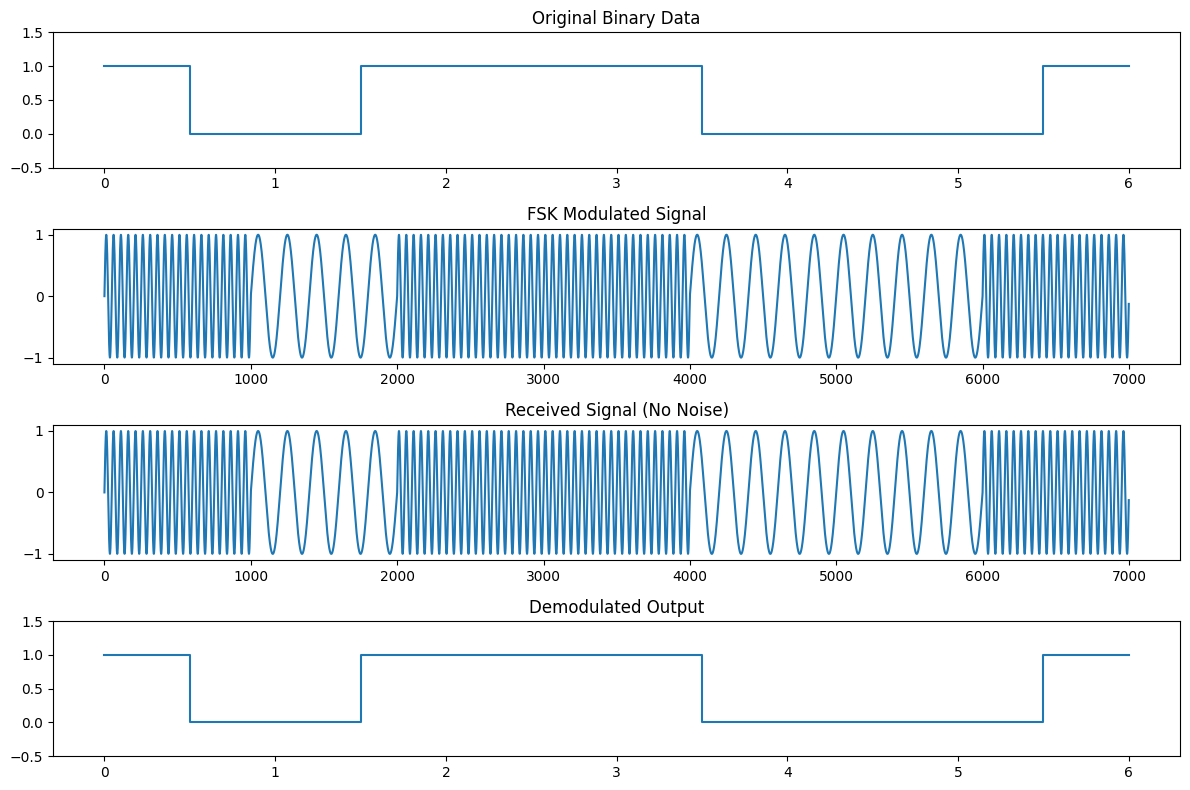

Original Data:      [1 0 1 1 0 0 1]
Demodulated Data:   [1 0 1 1 0 0 1]


In [ ]:
#fsk my
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000          # Sampling frequency
bit_duration = 1   # seconds per bit
f0 = 5             # Frequency for bit 0
f1 = 20            # Frequency for bit 1

# Binary data
data = np.array([1, 0, 1, 1, 0, 0, 1])

# Time axis for one bit
t = np.arange(0, bit_duration, 1/fs)

# -------------------------------
# FSK Modulation
# -------------------------------
fsk_signal = []

for bit in data:
    if bit == 1:
        carrier = np.sin(2 * np.pi * f1 * t)
    else:
        carrier = np.sin(2 * np.pi * f0 * t)
    fsk_signal.extend(carrier)

fsk_signal = np.array(fsk_signal)

# -------------------------------
# Received Signal (No Noise)
# -------------------------------
received_signal = fsk_signal.copy()

# -------------------------------
# Demodulation (Correlation)
# -------------------------------
samples_per_bit = len(t)
demodulated_bits = []

ref0 = np.sin(2 * np.pi * f0 * t)
ref1 = np.sin(2 * np.pi * f1 * t)

for i in range(0, len(received_signal), samples_per_bit):
    segment = received_signal[i:i+samples_per_bit]

    corr0 = np.sum(segment * ref0)
    corr1 = np.sum(segment * ref1)

    if corr1 > corr0:
        demodulated_bits.append(1)
    else:
        demodulated_bits.append(0)

demodulated_bits = np.array(demodulated_bits)

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(12, 8))

# Original Data
plt.subplot(4,1,1)
plt.title("Original Binary Data")
plt.step(range(len(data)), data, where='mid')
plt.ylim(-0.5, 1.5)

# FSK Signal
plt.subplot(4,1,2)
plt.title("FSK Modulated Signal")
plt.plot(fsk_signal)

# Received Signal
plt.subplot(4,1,3)
plt.title("Received Signal (No Noise)")
plt.plot(received_signal)

# Demodulated Data
plt.subplot(4,1,4)
plt.title("Demodulated Output")
plt.step(range(len(demodulated_bits)), demodulated_bits, where='mid')
plt.ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

# Print Results
print("Original Data:     ", data)
print("Demodulated Data:  ", demodulated_bits)

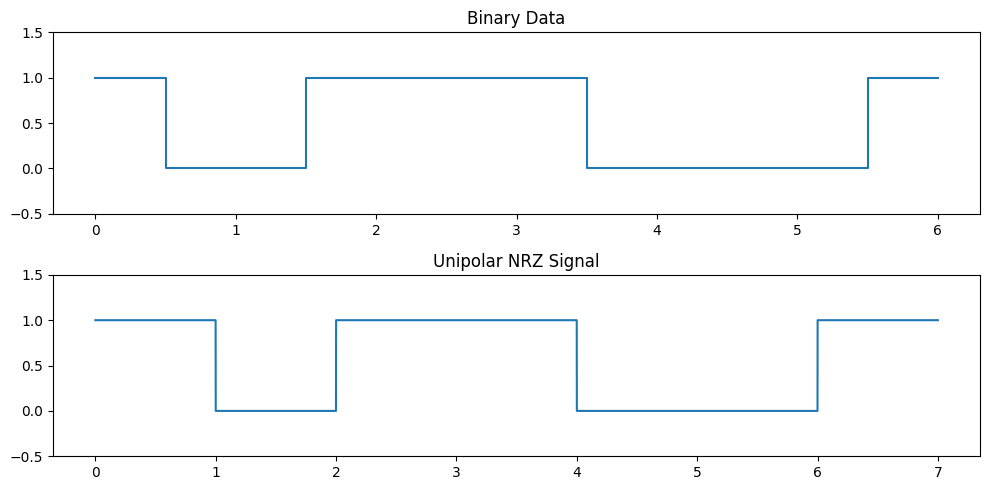

In [11]:
#Unipolar Non-Return-to-Zero (NRZ) my
import numpy as np
import matplotlib.pyplot as plt

# Parameters
bit_duration = 1      # duration of each bit
fs = 1000             # sampling frequency

# Binary data
data = np.array([1, 0, 1, 1, 0, 0, 1])

# Time axis for one bit
t = np.arange(0, bit_duration, 1/fs)

# -------------------------------
# Unipolar NRZ Signal Generation
# -------------------------------
nrz_signal = []

for bit in data:
    if bit == 1:
        level = np.ones_like(t)   # High level
    else:
        level = np.zeros_like(t)  # Zero level
    nrz_signal.extend(level)

nrz_signal = np.array(nrz_signal)

# Full time axis
total_time = np.arange(0, len(data)*bit_duration, 1/fs)

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(10, 5))

# Original Data
plt.subplot(2,1,1)
plt.title("Binary Data")
plt.step(range(len(data)), data, where='mid')
plt.ylim(-0.5, 1.5)

# NRZ Signal
plt.subplot(2,1,2)
plt.title("Unipolar NRZ Signal")
plt.plot(total_time, nrz_signal)
plt.ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

Unipolar Non-Return-to-Zero (NRZ) is a line coding technique where:

Binary data is represented using only positive voltage levels, and the signal does not return to zero between bits.

💡 Simple Idea:
Bit 1 → HIGH voltage
Bit 0 → ZERO voltage
Signal stays constant during the bit duration

👉 No transitions unless bit changes

🎯 Why NRZ is Used?
Very simple to implement
Used in:
Digital circuits
Data transmission (basic systems)
Memory storage
🔷 2. Core Concept
📊 Representation:
Bit	Signal
1	+V
0	0
🔁 “Non-Return-to-Zero” Meaning:
Signal does NOT go back to zero between bits
It only changes when bit changes
⚠️ Problem (Very Important for Viva)
Long sequence of 1s → no transitions → synchronization issue
Has DC component
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → Line Coding (NRZ) → Transmission → Receiver
🧠 Classification:
Concept	Type
NRZ	Line Coding
Signal	Baseband
Carrier	❌ Not used
Stage	Before modulation
🔥 Important Connection

👉 Compare with previous topics:

Stage	Technique
Baseband	NRZ (this lab)
Passband	ASK, PSK, FSK
🔷 4. Code Explanation (Line by Line)
⏱️ Parameters
bit_duration = 1
fs = 1000
Each bit lasts 1 second
1000 samples per second → smooth signal
🔢 Input Data
data = np.array([1, 0, 1, 1, 0, 0, 1])

👉 Binary sequence

⏳ Time for One Bit
t = np.arange(0, bit_duration, 1/fs)

👉 Time vector for a single bit

🔷 🔁 NRZ SIGNAL GENERATION
nrz_signal = []

👉 Initialize output signal

for bit in data:

👉 Loop through each bit

🔹 For Bit 1
level = np.ones_like(t)

👉 High voltage (constant +1)

🔹 For Bit 0
level = np.zeros_like(t)

👉 Zero voltage

nrz_signal.extend(level)

👉 Append each bit’s waveform

🔁 Convert to Array
nrz_signal = np.array(nrz_signal)
⏱️ Total Time Axis
total_time = np.arange(0, len(data)*bit_duration, 1/fs)

👉 Full signal timeline

🔷 5. Plotting
📊 Binary Data
plt.step(range(len(data)), data, where='mid')

👉 Shows original bits

📡 NRZ Signal
plt.plot(total_time, nrz_signal)

👉 Shows actual transmitted waveform

🔷 6. Output Understanding
1️⃣ Binary Data
Discrete bits (0 and 1)
2️⃣ NRZ Signal
Continuous signal:
Flat high for 1
Flat zero for 0
No return to zero between bits
🔷 7. Viva / Exam Questions
❓ What is NRZ?

NRZ is a line coding technique where signal does not return to zero between bits.

❓ Why called unipolar?

Because only positive voltage is used.

❓ Difference between NRZ and RZ?
NRZ → no return to zero
RZ → returns to zero within bit duration
❓ What is disadvantage of NRZ?
Synchronization problem
DC component present
❓ Where is NRZ used?
Baseband communication
Digital electronics
🔥 Final Intuition (Very Important)

Think like this:

👉 Bit stream → converted into voltage levels
👉 1 = HIGH, 0 = ZERO
👉 Signal stays flat → no unnecessary changes

🧠 Big Picture Summary (Connect All Labs)
Type	Technique	Stage
Line Coding	NRZ	Baseband
Pulse Modulation	PAM	Sampling
Digital Modulation	ASK, PSK, FSK	Passband

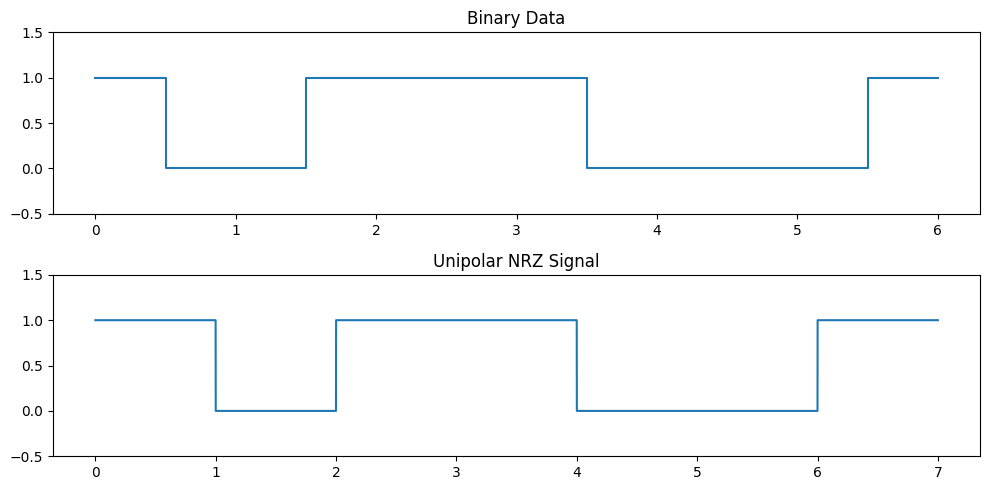

In [12]:
# uni nrz sir
import numpy as np
import matplotlib.pyplot as plt

# Parameters
bit_duration = 1
fs = 1000

# Input binary data
data = np.array([1, 0, 1, 1, 0, 0, 1])

# Time for one bit
t = np.arange(0, bit_duration, 1/fs)

# Generate NRZ signal
nrz_signal = []

for bit in data:
    if bit == 1:
        level = np.ones_like(t)   # High voltage
    else:
        level = np.zeros_like(t)  # Zero voltage
    nrz_signal.extend(level)

nrz_signal = np.array(nrz_signal)

# Total time axis
total_time = np.arange(0, len(data)*bit_duration, 1/fs)

# Plot
plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
plt.title("Binary Data")
plt.step(range(len(data)), data, where='mid')
plt.ylim(-0.5, 1.5)

plt.subplot(2,1,2)
plt.title("Unipolar NRZ Signal")
plt.plot(total_time, nrz_signal)
plt.ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

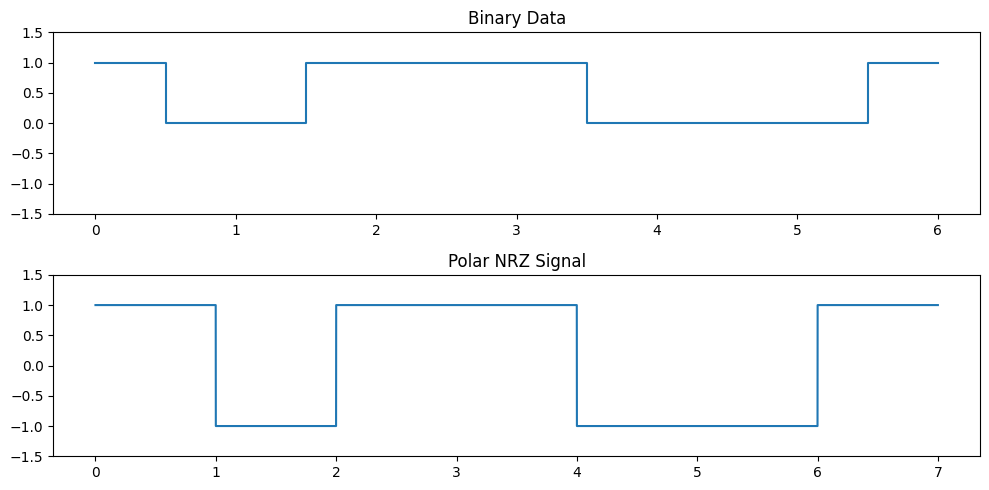

In [13]:
#polar nrz
import numpy as np
import matplotlib.pyplot as plt

# Parameters
bit_duration = 1
fs = 1000

# Input binary data
data = np.array([1, 0, 1, 1, 0, 0, 1])

# Time for one bit
t = np.arange(0, bit_duration, 1/fs)

# -------------------------------
# Polar NRZ Signal Generation
# -------------------------------
polar_nrz_signal = []

for bit in data:
    if bit == 1:
        level = np.ones_like(t)     # +1 for bit 1
    else:
        level = -np.ones_like(t)    # -1 for bit 0
    polar_nrz_signal.extend(level)

polar_nrz_signal = np.array(polar_nrz_signal)

# Total time axis
total_time = np.arange(0, len(data)*bit_duration, 1/fs)

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(10,5))

# Binary Data
plt.subplot(2,1,1)
plt.title("Binary Data")
plt.step(range(len(data)), data, where='mid')
plt.ylim(-1.5, 1.5)

# Polar NRZ Signal
plt.subplot(2,1,2)
plt.title("Polar NRZ Signal")
plt.plot(total_time, polar_nrz_signal)
plt.ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

Unipolar Return-to-Zero (RZ) is a line coding technique where:

Each bit returns to zero level within the bit duration, even if the next bit is the same.

💡 Simple Idea:
Bit 1 → HIGH for half time → then ZERO
Bit 0 → ZERO all the time

👉 So every bit has a return to zero point

🎯 Why RZ is Used?
Improves synchronization
Receiver can easily detect bit boundaries
🔷 2. Core Concept
📊 Representation:
Bit	Signal
1	+V → 0 (within same bit)
0	0
🔁 “Return-to-Zero” Meaning:
Signal always goes back to zero before next bit
Even if consecutive bits are same
🔥 Key Advantage:
More transitions → better clock recovery
⚠️ Disadvantages:
Requires more bandwidth
Still has DC component
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → Line Coding (RZ) → Transmission → Receiver
🧠 Classification:
Concept	Type
Unipolar RZ	Line Coding
Signal	Baseband
Carrier	❌ Not used
Stage	Before modulation
🔥 Compare with NRZ (Very Important)
Feature	NRZ	RZ
Return to zero	❌ No	✅ Yes
Synchronization	Poor ❌	Better ✅
Bandwidth	Low	High ❌
🔷 4. Code Explanation (Line by Line)
🔢 Number of Bits
N = 10

👉 Total bits

🎲 Random Data
n = np.random.randint(0, 2, N)

👉 Generates random binary sequence

⏱️ Samples per Bit
samples_per_bit = 100
half = samples_per_bit // 2

👉 Each bit is divided into:

First half
Second half
🔷 🔁 RZ SIGNAL GENERATION
y = []

👉 Initialize signal

for bit in n:

👉 Loop through each bit

🔹 If Bit = 1
y.extend([1] * half + [0] * half)

👉 Meaning:

First half → HIGH
Second half → ZERO

✔ This is Return-to-Zero behavior

🔹 If Bit = 0
y.extend([0] * samples_per_bit)

👉 Always zero

🔁 Convert to Array
y = np.array(y)
⏳ Time Axis
t = np.linspace(0, N, len(y))
🔷 5. Plotting
plt.step(t, y, where='post', linewidth=2)

👉 Step waveform:

Pulses for 1
Flat zero for 0
🔤 Show Bits
plt.text(i + 0.5, 1.2, str(n[i]))

👉 Displays bit values

🔷 6. Output Understanding
📊 You will see:
For bit 1:
Half pulse → then drop to zero
For bit 0:
Always zero

👉 Signal keeps returning to zero → easy timing detection

🔷 7. Viva / Exam Questions
❓ What is RZ signaling?

RZ is a line coding technique where signal returns to zero within each bit duration.

❓ Why RZ is better than NRZ?
Better synchronization
More transitions
❓ Why RZ is not widely used?
Requires more bandwidth
Power inefficient
❓ Difference between unipolar NRZ and RZ?
NRZ	RZ
No return to zero	Returns to zero
Less bandwidth	More bandwidth
❓ What is main disadvantage of unipolar RZ?

👉 Still has DC component

🔥 Final Intuition (Very Important)

Think like this:

👉 NRZ = hold the signal
👉 RZ = pulse and reset

🧠 Final Summary (Line Coding So Far)
Type	Levels	Key Feature
Unipolar NRZ	0, +V	No return
Polar NRZ	−V, +V	Balanced
Unipolar RZ	0, +V	Returns to zero
🔥 Very Important Exam Insight

👉 The evolution is:

Unipolar NRZ → Polar NRZ → RZ → Manchester

Each step tries to:

Reduce DC
Improve synchronization

If you want next (HIGHLY recommended):

👉 Manchester Encoding (very important, asked almost every year)
👉 Full comparison table of all line coding techniques (exam favorite)

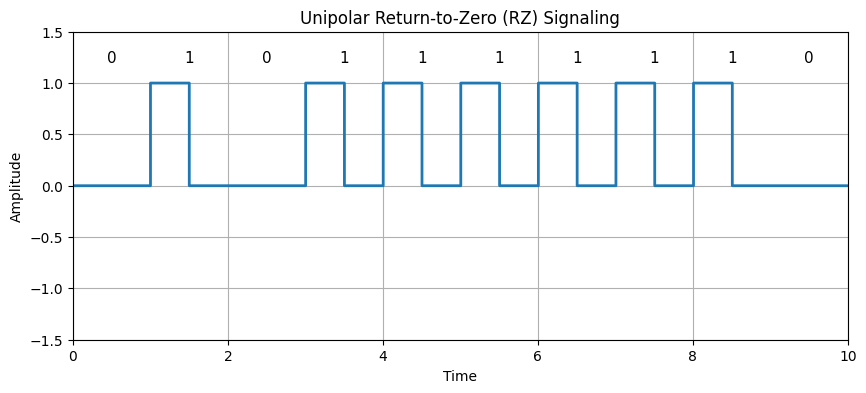

In [16]:
#uni rz sir
import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Generate random binary data
n = np.random.randint(0, 2, N)

# Samples per bit
samples_per_bit = 100
half = samples_per_bit // 2

# Generate Unipolar RZ signal
y = []

for bit in n:
    if bit == 1:
        y.extend([1] * half + [0] * half)   # 1 → high then zero
    else:
        y.extend([0] * samples_per_bit)     # 0 → always zero

y = np.array(y)

# Time axis
t = np.linspace(0, N, len(y))

# Plot
plt.figure(figsize=(10, 4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)

plt.title("Unipolar Return-to-Zero (RZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.grid()

# Show bit values on plot
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

Polar Non-Return-to-Zero (NRZ) is a line coding technique where:

Binary data is represented using two voltage levels: positive and negative, and the signal does not return to zero between bits.

💡 Simple Idea:
Bit 1 → +V (positive voltage)
Bit 0 → –V (negative voltage)

👉 Unlike unipolar:

No zero level
Signal swings between + and −
🎯 Why Polar NRZ is Better?
Reduces DC component
Better for transmission over channels
Easier synchronization than unipolar (but still not perfect)
🔷 2. Core Concept
📊 Representation:
Bit	Signal
1	+V
0	–V
🔁 “Non-Return-to-Zero” Meaning:
Signal stays constant during bit duration
Does not go to zero between bits
⚠️ Still Has Issues:
Long sequence of same bits → no transitions
Synchronization can still be difficult
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → Line Coding (Polar NRZ) → Transmission → Receiver
🧠 Classification:
Concept	Type
Polar NRZ	Line Coding
Signal	Baseband
Carrier	❌ Not used
Stage	Before modulation
🔥 Compare with Previous (Very Important)
Feature	Unipolar NRZ	Polar NRZ
Levels	0, +V	−V, +V
DC Component	High ❌	Reduced ✅
Performance	Poor	Better
🔷 4. Code Explanation (Line by Line)
🔢 Number of Bits
N = 10

👉 Total bits to generate

🎲 Random Binary Data
n = np.random.randint(0, 2, N)

👉 Generates random sequence like:

[1 0 1 1 0 ...]
🔁 Convert to Polar Form
nn = np.where(n == 1, 1, -1)
🔥 Very Important Line:
1 → +1
0 → −1

👉 This is polar encoding

⏱️ Samples per Bit
samples_per_bit = 100

👉 Smooth waveform

🔁 Create Signal
y = np.repeat(nn, samples_per_bit)

👉 Each bit becomes a flat level:

+1 or −1 over time
⏳ Time Axis
t = np.linspace(0, N, len(y))

👉 Time from 0 to N seconds

🔷 5. Plotting
📡 NRZ Signal
plt.step(t, y, where='post', linewidth=2)

👉 Step waveform:

+1 for bit 1
−1 for bit 0
🔤 Display Bits
plt.text(i + 0.5, 1.2, str(n[i]))

👉 Shows original bits above waveform

🔷 6. Output Understanding
📊 You will see:
Signal jumping between:
+1 → bit 1
−1 → bit 0

👉 No zero level at all

🔷 7. Viva / Exam Questions
❓ What is Polar NRZ?

A line coding technique where binary data is represented using positive and negative voltage levels.

❓ Why polar is better than unipolar?
Less DC component
Better transmission efficiency
❓ Why still not perfect?
Long sequences → no transitions → sync issue
❓ What is DC component?

A constant (average) value in the signal that wastes power.

❓ Difference between NRZ-L and NRZ-I?
NRZ-L → level represents bit
NRZ-I → transition represents bit
🔥 Final Intuition (Very Important)

Think like this:

👉 Instead of:

1 = ON, 0 = OFF (unipolar ❌)

We use:

1 = UP
0 = DOWN

👉 Signal keeps switching polarity → better balance

🧠 Final Summary (All Line Coding So Far)
Type	Levels	Issue
Unipolar NRZ	0, +V	High DC ❌
Polar NRZ	−V, +V	Sync issue ⚠️

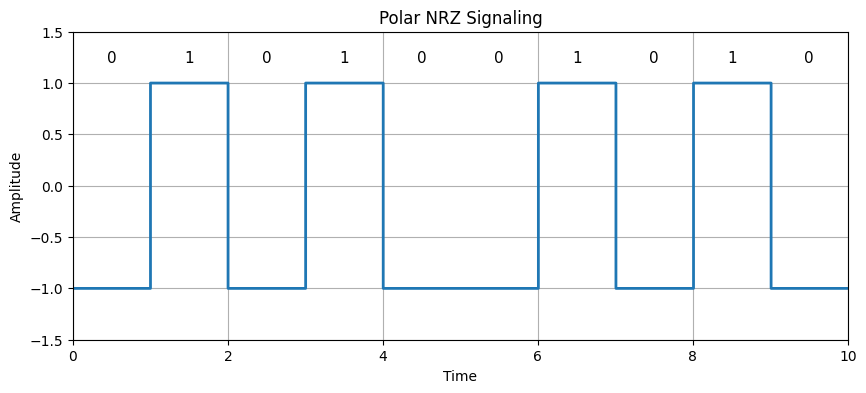

In [14]:
#polar nrz sir
import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Generate random binary data (0s and 1s)
n = np.random.randint(0, 2, N)

# Convert binary data to Polar NRZ:
# 1 → +1, 0 → -1
nn = np.where(n == 1, 1, -1)

# Number of samples per bit (for smooth plotting)
samples_per_bit = 100

# Repeat each bit value to create waveform
y = np.repeat(nn, samples_per_bit)

# Time axis
t = np.linspace(0, N, len(y))

# Plotting
plt.figure(figsize=(10, 4))

# Step plot for NRZ signal
plt.step(t, y, where='post', linewidth=2)

# Axis limits
plt.xlim(0, N)
plt.ylim(-1.5, 1.5)

# Labels and title
plt.title("Polar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

# Grid for better visualization
plt.grid()

# Display original bits on top of waveform
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

# Show plot
plt.show()

What is Bipolar Return-to-Zero (BRZ)?
4

Bipolar Return-to-Zero (BRZ) is a line coding technique where:

Binary 1s are represented by alternating positive and negative pulses, and each pulse returns to zero within the bit duration.

💡 Simple Idea:
Bit 1 → +V, then next 1 → −V, then next → +V (alternating)
Bit 0 → always 0
Every pulse → returns to zero
🎯 Why BRZ is Used?

It solves:

❌ DC component problem
❌ Synchronization problem

👉 So it is much better than unipolar & polar NRZ

🔷 2. Core Concept
📊 Representation:
Bit	Signal
1	+V, −V (alternating)
0	0
🔁 Key Features:
✅ Alternating Polarity

Consecutive 1s alternate:

+1, -1, +1, -1 ...
✅ Return to Zero
Each pulse:
Half bit → ±V
Half bit → 0
🔥 Why This is Powerful:
Problem	Solution in BRZ
DC component	Cancelled ✅
Synchronization	Improved ✅
Long 1s	Still transitions ✅
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → Line Coding (Bipolar RZ) → Transmission → Receiver
🧠 Classification:
Concept	Type
Bipolar RZ	Line Coding
Signal	Baseband
Carrier	❌ Not used
Stage	Before modulation
🔥 Evolution (VERY IMPORTANT)
Unipolar NRZ → Polar NRZ → RZ → Bipolar RZ → Manchester
🔷 4. Code Explanation (Line by Line)
🔢 Number of Bits
N = 10
🎲 Random Data
n = np.random.randint(0, 2, N)
🔷 🔁 Bipolar Encoding (MOST IMPORTANT PART)
nn = np.zeros(N)
polarity = 1

👉 polarity controls alternating + and −

for i in range(N):
    if n[i] == 1:
        nn[i] = polarity
        polarity *= -1
    else:
        nn[i] = 0
🔥 Key Idea:
If bit = 1:
Assign +1 or −1
Flip polarity for next 1

👉 Example:

Input:  1 1 1
Output: +1 -1 +1
🔷 🔁 RZ SIGNAL GENERATION
samples_per_bit = 100
half = samples_per_bit // 2
for val in nn:
🔹 If bit = 1 (±1)
y.extend([val] * half + [0] * half)

👉 Pulse then zero

🔹 If bit = 0
y.extend([0] * samples_per_bit)
⏳ Time Axis
t = np.linspace(0, N, len(y))
🔷 5. Plotting
plt.step(t, y, where='post', linewidth=2)

👉 Shows:

Positive pulses
Negative pulses
Return to zero
🔷 6. Output Understanding
📊 You will see:
Bit 1:
Alternating + and − pulses
Each returns to zero
Bit 0:
Flat zero

👉 Very dynamic waveform → easy to detect timing

🔷 7. Viva / Exam Questions
❓ What is Bipolar RZ?

A line coding technique where binary 1s are represented by alternating positive and negative pulses that return to zero.

❓ Why polarity alternates?

To eliminate DC component.

❓ Advantage over unipolar NRZ?
No DC
Better synchronization
❓ What is AMI?

Alternate Mark Inversion (same concept as bipolar)

❓ Why better than RZ?

Because it removes DC component while keeping synchronization.

🔥 Final Intuition (VERY IMPORTANT)

Think like this:

👉 Bit 1 = pulse
👉 But alternate direction (+ then −)
👉 And always reset to zero

🧠 Final Summary (All Line Coding)
Type	Levels	Key Feature
Unipolar NRZ	0, +V	Simple
Polar NRZ	−V, +V	Balanced
Unipolar RZ	0, +V	Returns to zero
Bipolar RZ	−V, 0, +V	Best balance ✅

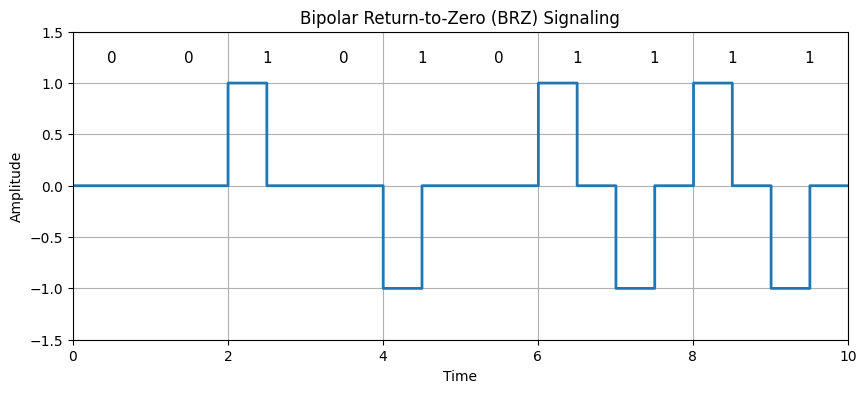

In [17]:
#bipolar rtz sir
import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Generate random binary data
n = np.random.randint(0, 2, N)

# Initialize bipolar sequence
nn = np.zeros(N)
polarity = 1

# Generate bipolar encoding (alternate polarity for 1s)
for i in range(N):
    if n[i] == 1:
        nn[i] = polarity
        polarity *= -1   # alternate polarity
    else:
        nn[i] = 0

# Samples per bit
samples_per_bit = 100
half = samples_per_bit // 2

# Generate BRZ signal
y = []

for val in nn:
    if val != 0:
        y.extend([val] * half + [0] * half)  # pulse then return to zero
    else:
        y.extend([0] * samples_per_bit)

y = np.array(y)

# Time axis
t = np.linspace(0, N, len(y))

# Plot
plt.figure(figsize=(10, 4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)

plt.title("Bipolar Return-to-Zero (BRZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.grid()

# Show bit values
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

Manchester Coding is a line coding technique where:

Each bit contains a transition in the middle of the bit duration, which carries the information.

💡 Simple Idea:
Bit 1 → High → Low transition
Bit 0 → Low → High transition

👉 The transition itself represents the data

🎯 Why Manchester is Used?
Built-in clock synchronization
No DC component
Very reliable

👉 Used in:

Ethernet (IEEE 802.3)
RFID
Digital communication systems
🔷 2. Core Concept
📊 Representation:
Bit	Signal
1	High → Low
0	Low → High
🔁 Key Feature (VERY IMPORTANT)

👉 Every bit has a transition in the middle

✔ This means:

Receiver always knows bit boundaries
No long flat signals
🔥 Why It Solves Everything
Problem	Solution
Synchronization	Fixed by transitions ✅
DC component	Eliminated ✅
Long same bits	Still transitions ✅
🔷 3. Where It Fits in Digital Communication (DC)
📶 Communication Chain:
Binary Data → Manchester Encoding → Transmission → Receiver
🧠 Classification:
Concept	Type
Manchester	Line Coding
Signal	Baseband
Carrier	❌ Not used
Stage	Before modulation
🔥 Final Evolution (VERY IMPORTANT)
Unipolar NRZ → Polar NRZ → RZ → Bipolar → Manchester ✅
🔷 4. Code Explanation (Line by Line)
🔢 Number of Bits
N = 10
🎲 Random Data
n = np.random.randint(0, 2, N)
🔷 🔁 Manchester Encoding (MOST IMPORTANT PART)
encoded = []
for bit in n:
🔹 If Bit = 1
encoded.extend([1, -1])

👉 High → Low transition

🔹 If Bit = 0
encoded.extend([-1, 1])

👉 Low → High transition

🔥 Key Idea:

Each bit is split into two halves

👉 So total length doubles

⏱️ Samples per Half Bit
samples_per_half_bit = 50

👉 Smooth waveform

🔁 Generate Signal
y = np.repeat(encoded, samples_per_half_bit)

👉 Expands each half-bit into waveform

⏳ Time Axis
t = np.linspace(0, N, len(y))
🔷 5. Plotting
plt.step(t, y, where='post', linewidth=2)

👉 Shows:

Clear transitions in middle of every bit
🔤 Show Bits
plt.text(i + 0.5, 1.2, str(n[i]))
🔷 6. Output Understanding
📊 You will see:
Every bit has a midpoint transition
No flat long signals
Alternating up-down patterns
🔷 7. Viva / Exam Questions (VERY IMPORTANT)
❓ What is Manchester coding?

Manchester coding is a line coding technique where each bit has a transition in the middle representing the data.

❓ Why is it called split-phase?

Because each bit is divided into two halves with opposite levels.

❓ Why Manchester is better than NRZ?
Provides synchronization
No DC component
❓ What is its disadvantage?

👉 Requires double bandwidth

❓ Where is it used?

👉 Ethernet (IEEE 802.3)

🔥 Final Intuition (VERY IMPORTANT)

Think like this:

👉 Instead of holding signal → we force a change every bit

👉 Bit is not level → bit is transition

🧠 Final Comparison (All Line Coding)
Technique	Sync	DC	Efficiency
Unipolar NRZ	❌	❌	High
Polar NRZ	❌	⚠️	High
RZ	⚠️	❌	Low
Bipolar	✅	✅	Medium
Manchester	✅✅	✅	Low ❌
🔥 Ultimate Exam Insight

👉 If examiner asks:
“Best line coding technique?”

✔ Answer:

Manchester (because of synchronization and no DC)

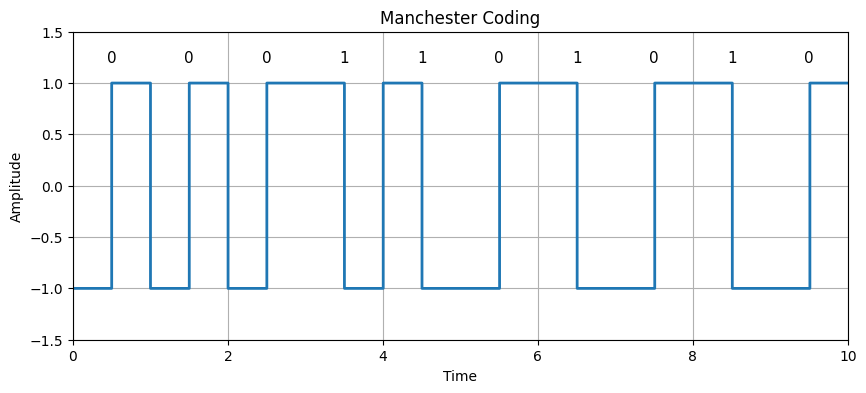

In [18]:
#manchester
import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Generate random binary data
n = np.random.randint(0, 2, N)

# Manchester encoding
encoded = []
for bit in n:
    if bit == 1:
        encoded.extend([1, -1])   # 1 → high to low
    else:
        encoded.extend([-1, 1])   # 0 → low to high

# Samples per half bit
samples_per_half_bit = 50

# Generate waveform
y = np.repeat(encoded, samples_per_half_bit)

# Time axis
t = np.linspace(0, N, len(y))

# Plot
plt.figure(figsize=(10, 4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)

plt.title("Manchester Coding")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.grid()

# Show bit values
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

Theory: QPSK (Quadrature Phase Shift Keying)
🔹 What is QPSK?

QPSK is a phase modulation technique where two bits are transmitted simultaneously per symbol by changing the phase of a carrier signal.

Each pair of bits → one of 4 possible phases
Increases data rate compared to BPSK (which sends 1 bit per symbol)
🔹 Phase Mapping
Bits	Phase	I (In-phase)	Q (Quadrature)
00	45°	1	1
01	135°	-1	1
11	225°	-1	-1
10	315°	1	-1
I component → cosine carrier
Q component → sine carrier
🔹 QPSK Signal Formula
𝑠
(
𝑡
)
=
𝐼
⋅
cos
⁡
(
2
𝜋
𝑓
𝑐
𝑡
)
+
𝑄
⋅
sin
⁡
(
2
𝜋
𝑓
𝑐
𝑡
)
s(t)=I⋅cos(2πf
c
	​

t)+Q⋅sin(2πf
c
	​

t)
𝑓
𝑐
f
c
	​

 → carrier frequency
𝐼
,
𝑄
I,Q → mapped symbols
🔹 Advantages of QPSK
Transmits 2 bits per symbol → double data rate
Bandwidth efficient compared to BPSK
Used in WiFi, LTE, Satellite Communication
🔹 Constellation Diagram
4
Each dot = 1 symbol (2 bits)
Shows phase of carrier
✅ 2. Where It Fits in Digital Communication (DC)

📚 QPSK is a Digital Bandpass Modulation technique.

Baseband → Line Coding → QPSK → Demodulation
Compared to ASK/FSK/BPSK → more bandwidth efficient
✅ 3. Concept Step-by-Step
Bit Generation: Generate a random sequence of 0s and 1s
Grouping: Group bits in pairs for 2 bits per symbol
Mapping: Map each bit pair → (I, Q) values using a mapping table
Modulation: Multiply I by cos carrier, Q by sin carrier → combine → QPSK signal
Transmission: Send the QPSK signal
Demodulation: Compare received I and Q → recover original bits
Constellation: Plot I vs Q to visualize phase positions
✅ 4. Code Explanation (Line-by-Line)
🔹 Generate Random Binary Data
data = np.random.randint(0, 2, 20)
pairs = data.reshape(-1, 2)
data → 20 bits
pairs → group bits in 2 for QPSK
🔹 Mapping to I and Q Symbols
map_dict = {(0,0):(1,1), (0,1):(-1,1), (1,1):(-1,-1), (1,0):(1,-1)}
symbols = np.array([map_dict[tuple(p)] for p in pairs])
I, Q = symbols[:,0], symbols[:,1]
Converts bit pairs → ±1 (polar mapping)
I → in-phase, Q → quadrature
🔹 Generate QPSK Signal
t = np.linspace(0,1,100)
fc = 5
signal = np.concatenate([I[i]*np.cos(2*np.pi*fc*t) + Q[i]*np.sin(2*np.pi*fc*t) for i in range(len(I))])
Time array for one symbol
Multiply I → cos carrier, Q → sin carrier
Concatenate → full signal
🔹 Demodulation
demod = []
for i, q in zip(I, Q):
    if i>0 and q>0: demod+=[0,0]
    elif i<0 and q>0: demod+=[0,1]
    elif i<0 and q<0: demod+=[1,1]
    else: demod+=[1,0]
demod = np.array(demod)
Checks quadrant of (I,Q)
Recovers original 2 bits per symbol
🔹 Plotting
Original Signal: step plot of bits
QPSK Modulated Signal: time-domain waveform
Demodulated Signal: step plot to compare
Constellation: scatter plot of I vs Q
✅ 5. Output Interpretation
🔹 Original Binary Data
Sequence of 0s and 1s
🔹 QPSK Signal
Sinusoidal waveform
Phase changes according to bit pairs
🔹 Demodulated Data
Should match original bits
🔹 Constellation Diagram
4 points (±1, ±1) → shows symbol mapping
Quadrants indicate phase of each symbol
✅ 6. Important Viva Questions
🔸 Q1: Why use QPSK over BPSK?
2 bits per symbol → double data rate
🔸 Q2: How many phases in QPSK?
4 phases
🔸 Q3: What are I and Q components?
I = cos carrier, Q = sin carrier, orthogonal
🔸 Q4: Advantage of QPSK?
Efficient bandwidth, reliable
🔸 Q5: Real-world use?
WiFi, LTE, Satellite, DVB
🔸 Q6: How to detect symbol in demodulation?
Check quadrant of (I, Q) → map to bits
🔥 Final Exam Line

“QPSK modulates two bits per symbol by varying the phase of a carrier using I and Q components; constellation diagram shows the 4 possible symbol phases.”

Original Data: [1 1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1]
Demodulated Data: [1 1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1]


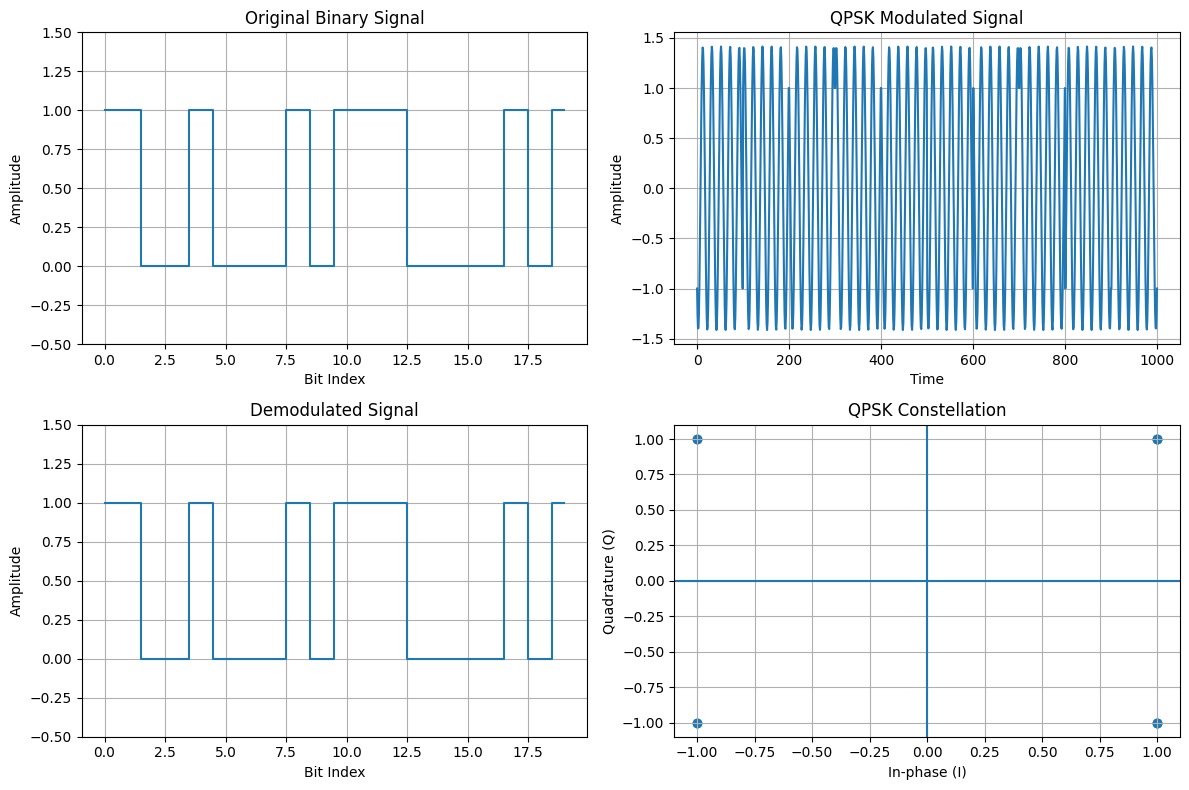

In [8]:
#qpsk
import numpy as np
import matplotlib.pyplot as plt

# Generate random binary data
data = np.random.randint(0, 2, 20)

# Group bits into pairs
pairs = data.reshape(-1, 2)

# Mapping dictionary
map_dict = {
    (0, 0): (1, 1),
    (0, 1): (-1, 1),
    (1, 1): (-1, -1),
    (1, 0): (1, -1)
}

# Map bits to symbols
symbols = np.array([map_dict[tuple(p)] for p in pairs])
I, Q = symbols[:, 0], symbols[:, 1]

# Time and carrier frequency
t = np.linspace(0, 1, 100)
fc = 5

# Generate QPSK signal
signal = np.concatenate([
    I[i]*np.cos(2*np.pi*fc*t) + Q[i]*np.sin(2*np.pi*fc*t)
    for i in range(len(I))
])

# Demodulation
demod = []
for i, q in zip(I, Q):
    if i > 0 and q > 0:
        demod += [0, 0]
    elif i < 0 and q > 0:
        demod += [0, 1]
    elif i < 0 and q < 0:
        demod += [1, 1]
    else:
        demod += [1, 0]

demod = np.array(demod)

# Plotting
plt.figure(figsize=(12, 8))

# Original Signal
plt.subplot(2, 2, 1)
plt.step(range(len(data)), data, where='mid')
plt.title("Original Binary Signal")
plt.xlabel("Bit Index")
plt.ylabel("Amplitude")
plt.ylim(-0.5, 1.5)
plt.grid()

# Modulated Signal
plt.subplot(2, 2, 2)
plt.plot(signal)
plt.title("QPSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Demodulated Signal
plt.subplot(2, 2, 3)
plt.step(range(len(demod)), demod, where='mid')
plt.title("Demodulated Signal")
plt.xlabel("Bit Index")
plt.ylabel("Amplitude")
plt.ylim(-0.5, 1.5)
plt.grid()

# Constellation
plt.subplot(2, 2, 4)
plt.scatter(I, Q)
plt.title("QPSK Constellation")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axhline(0)
plt.axvline(0)
plt.grid()

plt.tight_layout()

# Print data
print("Original Data:", data)
print("Demodulated Data:", demod)

plt.show()

Theory: 16-QAM (Quadrature Amplitude Modulation)
🔹 What is QAM?

QAM (Quadrature Amplitude Modulation) is a modulation technique where:

Both amplitude and phase of the carrier are varied to transmit data.

Combines ASK (amplitude variation) + PSK (phase variation)
More bandwidth efficient than PSK alone
🔹 16-QAM
16-QAM → 16 symbols
Each symbol represents 4 bits (since 2⁴ = 16)
Uses I (In-phase) and Q (Quadrature) components
🔹 Symbol Mapping
Bits	I	Q
00 00	-3	-3
00 01	-3	-1
00 11	-3	1
00 10	-3	3
01 00	-1	-3
...	...	...
11 10	3	3
I → first 2 bits
Q → last 2 bits
🔹 Constellation Diagram
4
16 points form a grid in I-Q plane
Each point = 1 symbol (4 bits)
Shows both amplitude & phase information
🔹 Mathematical Representation
𝑠
(
𝑡
)
=
𝐼
⋅
cos
⁡
(
2
𝜋
𝑓
𝑐
𝑡
)
−
𝑄
⋅
sin
⁡
(
2
𝜋
𝑓
𝑐
𝑡
)
s(t)=I⋅cos(2πf
c
	​

t)−Q⋅sin(2πf
c
	​

t)
𝐼
,
𝑄
I,Q → mapped amplitude levels
𝑓
𝑐
f
c
	​

 → carrier frequency
🔹 Advantages
High spectral efficiency
Can transmit more bits per symbol
Used in WiFi, LTE, 5G, Digital TV
🔹 Disadvantages
More susceptible to noise than PSK
Requires precise amplitude and phase control
✅ 2. Where It Fits in Digital Communication

📚 QAM is a Digital Bandpass Modulation technique:

Baseband → Line coding → 16-QAM → Demodulation
Compared to BPSK/QPSK, it sends more bits per symbol, improving data rate
✅ 3. Concept Step-by-Step
Bit Generation: Generate random bits
Grouping: Group 4 bits per symbol
Mapping: Map first 2 bits → I, last 2 bits → Q (Amplitude levels: ±3, ±1)
Modulation: Form complex symbol: 
𝑠
=
𝐼
+
𝑗
𝑄
s=I+jQ
Transmission: Send symbol over channel
Constellation: Scatter plot of I vs Q → visualizes all symbols
✅ 4. Code Explanation (Line-by-Line)
🔹 Generate Bits and Group
bits = np.random.randint(0, 2, N * 4)
bit_groups = bits.reshape((N, 4))
N = 200 symbols
4 bits per symbol → 200 × 4 = 800 bits
🔹 Mapping Bits → Amplitude Levels
mapping = {(0,0):-3, (0,1):-1, (1,1):1, (1,0):3}
I = np.array([mapping[tuple(b[:2])] for b in bit_groups])
Q = np.array([mapping[tuple(b[2:])] for b in bit_groups])
First 2 bits → I
Last 2 bits → Q
Amplitude levels: ±3, ±1
🔹 Form QAM Signal
qam_signal = I + 1j*Q
Complex number: real → I, imaginary → Q
Can be transmitted as cos/sin carriers
🔹 Plot I/Q Components vs Symbol Index
plt.plot(t, np.real(qam_signal), label='In-phase (I)')
plt.plot(t, np.imag(qam_signal), label='Quadrature (Q)')
Shows how I and Q vary symbol by symbol
🔹 Plot Constellation
plt.scatter(np.real(qam_signal), np.imag(qam_signal))
plt.xticks([-3,-1,1,3])
plt.yticks([-3,-1,1,3])
plt.grid()
plt.axis('equal')
Each point → 1 symbol
Grid shows 16 points for 16-QAM
✅ 5. Output Interpretation
🔹 I and Q Components
Step-like signal
I and Q can take values: ±3, ±1
🔹 Constellation Diagram
16 distinct points in I-Q plane
Each point = 1 symbol = 4 bits
Visual confirmation of modulation correctness
✅ 6. Important Viva Questions
🔸 Q1: How many bits per symbol in 16-QAM?
4 bits/symbol
🔸 Q2: Why is QAM better than PSK?
Combines amplitude & phase modulation → more bits/symbol → higher spectral efficiency
🔸 Q3: What are I and Q components?
Orthogonal components of carrier
I → cos, Q → sin
🔸 Q4: What are the amplitude levels in 16-QAM?
±1, ±3 (for normalized mapping)
🔸 Q5: Real-world applications?
WiFi, LTE, Digital TV, DSL, 5G
🔸 Q6: Disadvantages?
More sensitive to noise & distortion than QPSK
🔥 Final Exam Line

“16-QAM transmits 4 bits per symbol using both amplitude and phase variations; its constellation diagram shows 16 distinct points corresponding to all possible 4-bit combinations.”

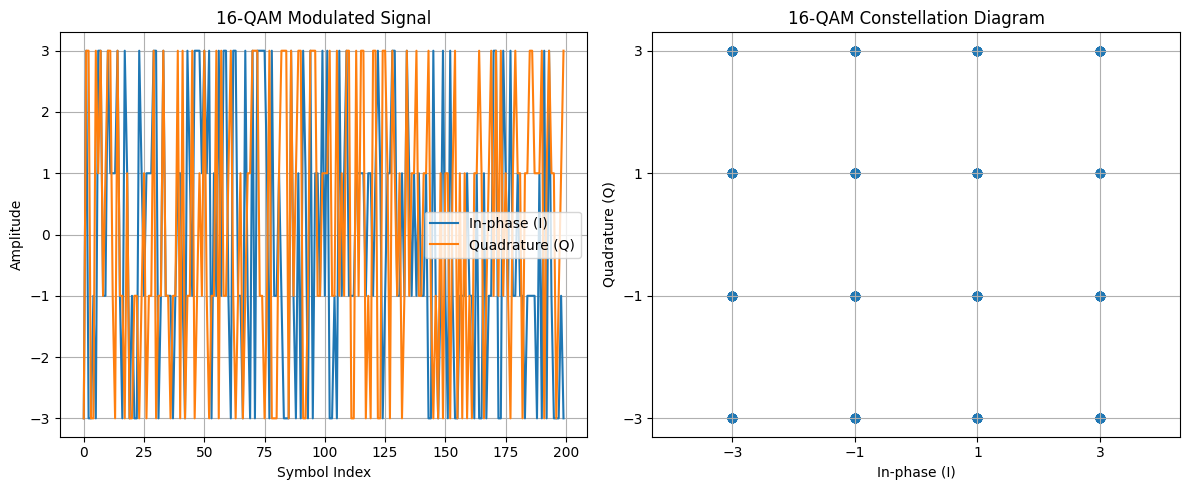

In [ ]:
#Generate 16-QAM modulation and obtain the QAM constellation using MATLAB/ Python
import numpy as np
import matplotlib.pyplot as plt

# Number of symbols
N = 200

# Generate random bits (4 bits per symbol)
bits = np.random.randint(0, 2, N * 4)

# Group into 4-bit symbols
bit_groups = bits.reshape((N, 4))

# Mapping dictionary
mapping = {
    (0, 0): -3,
    (0, 1): -1,
    (1, 1): 1,
    (1, 0): 3
}

# Map bits to I and Q components
I = np.array([mapping[tuple(b[:2])] for b in bit_groups])
Q = np.array([mapping[tuple(b[2:])] for b in bit_groups])

# Generate QAM signal
qam_signal = I + 1j * Q

# Time index
t = np.arange(N)

# Plotting
plt.figure(figsize=(12, 5))

# I and Q components
plt.subplot(1, 2, 1)
plt.plot(t, np.real(qam_signal), label='In-phase (I)')
plt.plot(t, np.imag(qam_signal), label='Quadrature (Q)')
plt.title("16-QAM Modulated Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

# Constellation Diagram
plt.subplot(1, 2, 2)
plt.scatter(np.real(qam_signal), np.imag(qam_signal))
plt.title("16-QAM Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])
plt.grid()
plt.axis('equal')

plt.tight_layout()
plt.show()

Theory: Sampling & Reconstruction
🔹 What is Sampling?

Sampling is the process of converting a continuous-time signal into a discrete-time signal by taking values at specific time intervals.

👉 Example:

Continuous signal → infinite points
Sampled signal → finite points
🔹 Sampling Theorem (VERY IMPORTANT)

𝑓
𝑠
≥
2
𝑓
𝑚
f
s
	​

≥2f
m
	​


👉 Where:

𝑓
𝑠
f
s
	​

 = sampling frequency
𝑓
𝑚
f
m
	​

 = maximum signal frequency

💡 This is called the Nyquist Theorem

🔹 Reconstruction

Reconstruction means:

Recovering the original continuous signal from sampled data

🔹 Ideal vs Practical
Ideal → sinc interpolation
Practical → linear interpolation (used in your code)
🔹 Sampling Visualization
4
✅ 2. Where It Fits in Digital Communication (DC)

📚 This belongs to:

👉 Analog to Digital Conversion

Flow:
Sampling ✅ (this lab)
Quantization
Encoding (PCM, DPCM)

👉 So this is the first step of all digital communication systems

✅ 3. Concept Explanation (Step-by-Step)
🔹 Step 1: Continuous Signal
𝑥
(
𝑡
)
=
sin
⁡
(
2
𝜋
𝑓
𝑡
)
x(t)=sin(2πft)
🔹 Step 2: Sampling

Take values at intervals:

𝑡
=
0
,
1
𝑓
𝑠
,
2
𝑓
𝑠
,
.
.
.
t=0,
f
s
	​

1
	​

,
f
s
	​

2
	​

,...
🔹 Step 3: Discrete Signal
𝑥
[
𝑛
]
=
𝑥
(
𝑛
𝑇
𝑠
)
x[n]=x(nT
s
	​

)
🔹 Step 4: Reconstruction

Use interpolation to rebuild:

Linear interpolation (your code)
Sinc (ideal)

💡 Key Idea for Viva:

“If sampling frequency is below Nyquist rate, aliasing occurs.”

✅ 4. Code Explanation (Line by Line)
🔹 Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
numpy → math operations
matplotlib → plotting
interp1d → interpolation (reconstruction)
🔹 Continuous Signal
t = np.linspace(0, 1, 1000)
f = 5
x = np.sin(2 * np.pi * f * t)

👉 Generates smooth sine wave

1000 points → looks continuous
🔹 Sampling
fs = 20
ts = np.arange(0, 1, 1/fs)
xs = np.sin(2 * np.pi * f * ts)

👉 Sampling frequency:

𝑓
𝑠
=
20
f
s
	​

=20 Hz
Signal frequency = 5 Hz

✔ Nyquist satisfied:

20
≥
2
×
5
20≥2×5
🔹 Reconstruction
interp_func = interp1d(ts, xs, kind='linear')

👉 Creates interpolation function

t_new = np.linspace(ts.min(), ts.max(), 1000)
x_recon = interp_func(t_new)

👉 Reconstructs signal using:

Linear interpolation
🔹 Plotting

Three plots:

Original signal
Sampled signal (stem plot)
Reconstructed signal
✅ 5. Output Interpretation (VERY IMPORTANT)
4
🔹 1. Original Signal
Smooth sine wave
🔹 2. Sampled Signal
Discrete points
Represent actual transmitted data
🔹 3. Reconstructed Signal
Close to original
Slight error due to linear interpolation

💡 Viva Tip:

“Reconstructed signal matches original when sampling theorem is satisfied.”

✅ 6. Important Viva Questions
🔸 Q1: What is sampling?

👉 Converting continuous signal into discrete form

🔸 Q2: What is Nyquist rate?

👉 Minimum sampling rate = 2 × max frequency

🔸 Q3: What is aliasing?

👉 Overlapping of spectra due to undersampling

🔸 Q4: Why interpolation is needed?

👉 To reconstruct continuous signal

🔸 Q5: Types of interpolation?
Linear
Sinc (ideal)
🔸 Q6: What happens if fs < 2fm?

👉 Distortion (aliasing)

🔥 Final Exam Line (Must Remember)

“Sampling converts a continuous signal into discrete form, and accurate reconstruction is possible when the sampling frequency satisfies the Nyquist criterion.”

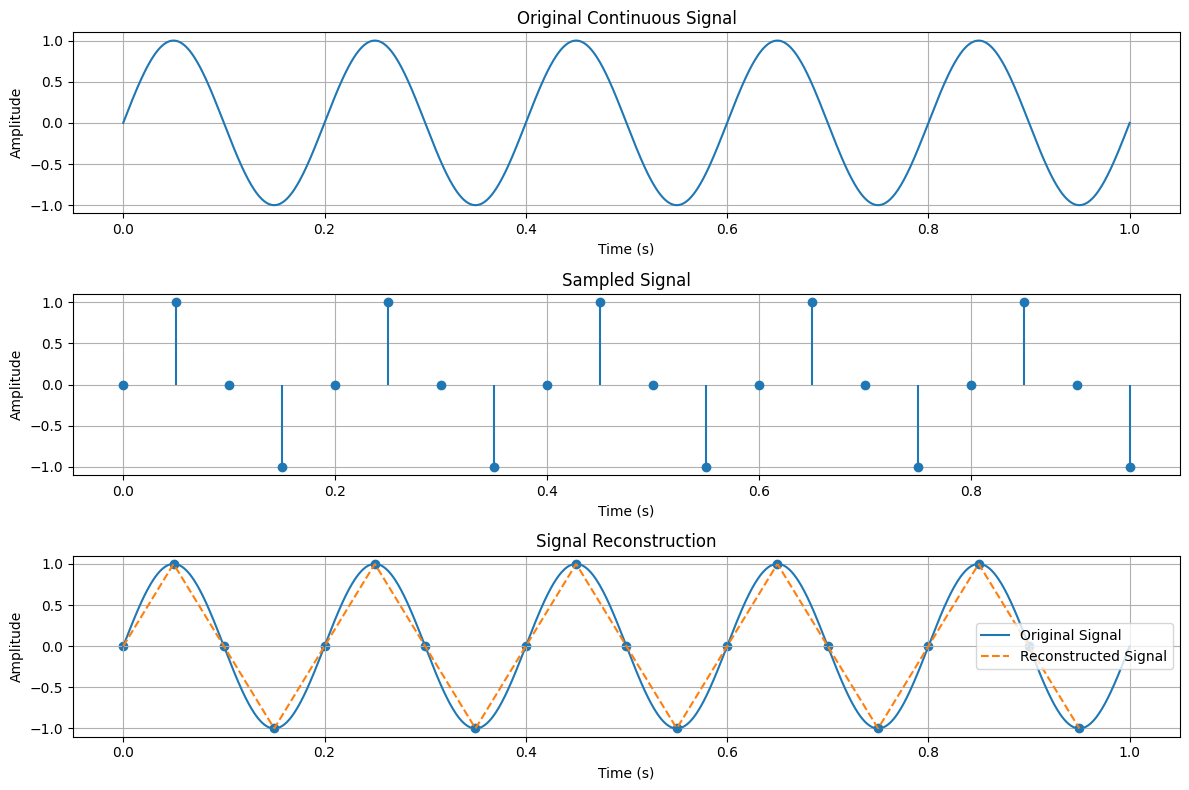

In [1]:
#Perform Sampling and Reconstruction of a Continuous Signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Continuous signal
t = np.linspace(0, 1, 1000)
f = 5
x = np.sin(2 * np.pi * f * t)

# Sampling
fs = 20
ts = np.arange(0, 1, 1/fs)
xs = np.sin(2 * np.pi * f * ts)

# Reconstruction using interpolation
interp_func = interp1d(ts, xs, kind='linear')
t_new = np.linspace(ts.min(), ts.max(), 1000)
x_recon = interp_func(t_new)

# Plotting
plt.figure(figsize=(12, 8))

# Original signal
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title("Original Continuous Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

# Sampled signal
plt.subplot(3, 1, 2)
plt.stem(ts, xs, basefmt=" ")
plt.title("Sampled Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

# Reconstruction
plt.subplot(3, 1, 3)
plt.plot(t, x, label="Original Signal")
plt.plot(t_new, x_recon, '--', label="Reconstructed Signal")
plt.scatter(ts, xs)
plt.title("Signal Reconstruction")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

1. Theory: What is QPSK?
🔹 Definition

QPSK (Quadrature Phase Shift Keying) is a digital modulation technique where:

Two bits are transmitted at a time by changing the phase of the carrier signal.

🔹 Key Idea
1 bit → 2 phases (BPSK)
2 bits → 4 phases (QPSK)

👉 So QPSK transmits double data rate compared to BPSK

🔹 Phase Mapping

Each pair of bits corresponds to a phase:

Bits	Phase
00	45°
01	135°
11	225°
10	315°
🔹 Constellation Diagram
4

👉 Each point represents:

One symbol (2 bits)
Defined by I (In-phase) and Q (Quadrature) components
✅ 2. Where It Fits in Digital Communication (DC)

📚 QPSK belongs to:

👉 Digital Bandpass Modulation

Flow:
Baseband → PAM → PCM
ASK / FSK / PSK → QPSK → QAM

👉 So:

QPSK = advanced version of PSK
Used in real systems (WiFi, LTE, Satellite)
✅ 3. Concept Explanation (Step-by-Step)
🔹 Step 1: Bit Grouping

Instead of sending 1 bit:

(
0
,
1
,
1
,
0
)
→
(
01
)
,
(
10
)
(0,1,1,0)→(01),(10)
🔹 Step 2: Mapping to I & Q

Each pair → (I, Q)

Example:

(0,0) → (1,1)
(1,1) → (-1,-1)
🔹 Step 3: Carrier Signals

Two carriers:

I → cosine
Q → sine
🔹 Step 4: Signal Generation
𝑠
(
𝑡
)
=
𝐼
cos
⁡
(
2
𝜋
𝑓
𝑐
𝑡
)
−
𝑄
sin
⁡
(
2
𝜋
𝑓
𝑐
𝑡
)
s(t)=Icos(2πf
c
	​

t)−Qsin(2πf
c
	​

t)
🔹 Step 5: Final Signal
Combination of I and Q
Produces phase-shifted waveform

💡 Viva Line:

“QPSK transmits 2 bits per symbol using four different carrier phases.”

✅ 4. Code Explanation (Line by Line)
🔹 Import Libraries
import numpy as np
import matplotlib.pyplot as plt
🔹 Parameters
num_bits = 20
fc = 5
samples_per_bit = 100
fc → carrier frequency
samples_per_bit → waveform resolution
🔹 Generate Bits
bits = np.random.randint(0, 2, num_bits)
🔹 Ensure Even Bits
bits = bits[:len(bits) - len(bits)%2]

👉 QPSK needs pairs of bits

🔹 Group Bits
bit_pairs = bits.reshape(-1, 2)

👉 Example:

[1,0,1,1] → [[1,0], [1,1]]
🔹 Mapping Table (VERY IMPORTANT)
mapping = {
    (0, 0): (1, 1),
    (0, 1): (-1, 1),
    (1, 1): (-1, -1),
    (1, 0): (1, -1)
}

👉 Converts bits → (I, Q)

🔹 Generate I & Q Signals
I, Q = [], []
for pair in bit_pairs:
    i, q = mapping[tuple(pair)]
    I.extend([i] * samples_per_bit)
    Q.extend([q] * samples_per_bit)

👉 Each symbol becomes a constant waveform segment

🔹 Convert to Arrays
I = np.array(I)
Q = np.array(Q)
🔹 Time Axis
t = np.arange(len(I)) / samples_per_bit
🔹 Carrier Signals
carrier_I = np.cos(2 * np.pi * fc * t)
carrier_Q = np.sin(2 * np.pi * fc * t)

👉 Two orthogonal carriers:

Cosine → I
Sine → Q
🔹 QPSK Signal (MOST IMPORTANT)
qpsk_signal = I * carrier_I - Q * carrier_Q

👉 Formula:

𝑠
(
𝑡
)
=
𝐼
cos
⁡
(
.
.
.
)
−
𝑄
sin
⁡
(
.
.
.
)
s(t)=Icos(...)−Qsin(...)
✅ 5. Output Interpretation
4
🔹 1. I (In-phase)
Step-like signal
Represents part of data
🔹 2. Q (Quadrature)
Another step signal
90° shifted conceptually
🔹 3. QPSK Signal
Smooth sinusoidal waveform
Phase changes based on bits

💡 Viva Tip:

“Phase of the carrier changes according to bit pairs, not amplitude.”

✅ 6. Important Viva Questions
🔸 Q1: Why QPSK is better than BPSK?

👉 Sends 2 bits per symbol → higher data rate

🔸 Q2: What are I and Q?

👉 Two orthogonal components (cosine & sine)

🔸 Q3: Why sine and cosine?

👉 They are orthogonal → no interference

🔸 Q4: How many phases in QPSK?

👉 4 phases

🔸 Q5: Bandwidth efficiency?

👉 Higher than BPSK

🔸 Q6: Real-life use?

👉 WiFi, LTE, Satellite communication

🔥 Final Exam Line (Must Remember)

“QPSK transmits two bits per symbol by modulating the phase of a carrier using orthogonal I and Q components.”

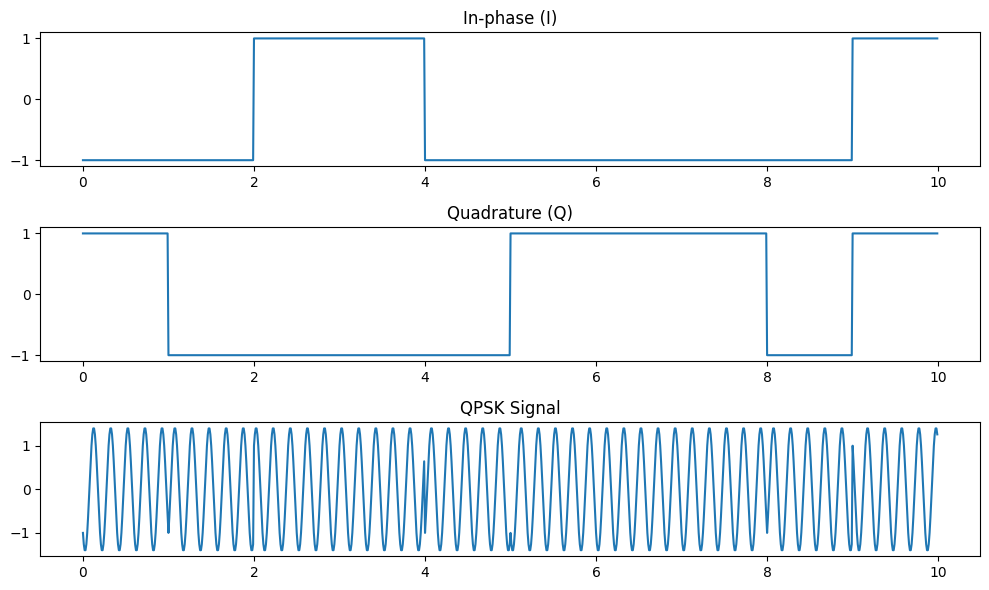

In [23]:
#To generate the waveform of Quadrature Phase Shift Keying signal using MATLAB/Python.
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_bits = 20
fc = 5
samples_per_bit = 100

# Generate random bits
bits = np.random.randint(0, 2, num_bits)

# Ensure even number of bits
bits = bits[:len(bits) - len(bits)%2]

# Group bits into pairs
bit_pairs = bits.reshape(-1, 2)

# Mapping (I, Q)
mapping = {
    (0, 0): (1, 1),
    (0, 1): (-1, 1),
    (1, 1): (-1, -1),
    (1, 0): (1, -1)
}

# Generate I and Q signals
I, Q = [], []
for pair in bit_pairs:
    i, q = mapping[tuple(pair)]
    I.extend([i] * samples_per_bit)
    Q.extend([q] * samples_per_bit)

I = np.array(I)
Q = np.array(Q)

# Time axis
t = np.arange(len(I)) / samples_per_bit

# Carrier signals
carrier_I = np.cos(2 * np.pi * fc * t)
carrier_Q = np.sin(2 * np.pi * fc * t)

# QPSK signal
qpsk_signal = I * carrier_I - Q * carrier_Q

# Plotting
plt.figure(figsize=(10, 6))

# I component
plt.subplot(3, 1, 1)
plt.plot(t, I)
plt.title("In-phase (I)")

# Q component
plt.subplot(3, 1, 2)
plt.plot(t, Q)
plt.title("Quadrature (Q)")

# QPSK signal
plt.subplot(3, 1, 3)
plt.plot(t, qpsk_signal)
plt.title("QPSK Signal")

plt.tight_layout()
plt.show()

1. Theory: What is DPCM?
🔹 Definition

DPCM (Differential Pulse Code Modulation) is a signal compression technique where we encode the difference between consecutive samples instead of encoding the full signal.

🔹 Why DPCM is used?
In normal PCM → we encode full amplitude → more bits required
In DPCM → we encode only change (difference) → fewer bits required

👉 Because adjacent samples are highly correlated

🔹 Basic Idea

Instead of:

𝑥
(
𝑛
)
x(n)

We encode:

𝑒
(
𝑛
)
=
𝑥
(
𝑛
)
−
𝑥
(
𝑛
−
1
)
e(n)=x(n)−x(n−1)
🔹 Block Diagram Concept
4

At Transmitter:

Predictor → predicts current value
Subtractor → finds error
Quantizer → quantizes error
Encoder → sends bits

At Receiver:

Decoder → gets quantized error
Adder → reconstructs signal
✅ 2. Where It Fits in Digital Communication (DC)

📚 This belongs to:

👉 Source Coding / Waveform Coding

Under: Analog → Digital Conversion
Flow:
PAM → PCM → DPCM → DM (Delta Modulation)

👉 So DPCM is an improved version of PCM (compression technique)

✅ 3. Concept Explanation (Step-by-Step)
🔹 Step 1: Signal Generation

We take an analog signal:

𝑥
(
𝑡
)
=
sin
⁡
(
2
𝜋
𝑓
𝑡
)
x(t)=sin(2πft)
🔹 Step 2: Prediction

We assume:

Predicted value
=
𝑥
(
𝑛
−
1
)
Predicted value=x(n−1)
🔹 Step 3: Error Calculation
𝑒
(
𝑛
)
=
𝑥
(
𝑛
)
−
𝑥
^
(
𝑛
)
e(n)=x(n)−
x
^
(n)
🔹 Step 4: Quantization

Error is quantized:

𝑒
𝑞
(
𝑛
)
=
round
(
𝑒
(
𝑛
)
/
Δ
)
×
Δ
e
q
	​

(n)=round(e(n)/Δ)×Δ

Where:

Δ
Δ = step size
🔹 Step 5: Reconstruction
𝑥
^
(
𝑛
)
=
𝑥
^
(
𝑛
−
1
)
+
𝑒
𝑞
(
𝑛
)
x
^
(n)=
x
^
(n−1)+e
q
	​

(n)

💡 Key Idea for Viva:

“DPCM reduces redundancy by encoding only the difference between successive samples.”

✅ 4. Code Explanation (Line by Line)
🔹 Import Libraries
import numpy as np
import matplotlib.pyplot as plt
numpy → numerical operations
matplotlib → plotting signals
🔹 Generate Signal
t = np.linspace(0, 1, 200)
x = np.sin(2 * np.pi * 5 * t)
t → time axis (0 to 1 sec, 200 samples)
x → sine wave (5 Hz signal)
🔹 Quantization Step Size
step_size = 0.2
Controls accuracy
Smaller step → better quality but more bits
🔹 Initialize Arrays
predicted = np.zeros_like(x)
error = np.zeros_like(x)
q_error = np.zeros_like(x)
predicted → predicted values
error → difference signal
q_error → quantized error
🔹 DPCM Encoding
for i in range(1, len(x)):
    predicted[i] = x[i - 1]

👉 Predictor assumes:

Current value ≈ previous value
    error[i] = x[i] - predicted[i]

👉 Calculates difference

    q_error[i] = step_size * np.round(error[i] / step_size)

👉 Quantization:

Divide by step size
Round it
Multiply back
🔹 DPCM Decoding
reconstructed = np.zeros_like(x)
for i in range(1, len(x)):
    reconstructed[i] = reconstructed[i - 1] + q_error[i]

👉 Reconstruction formula:

Previous output + quantized error
✅ 5. Output Interpretation (VERY IMPORTANT FOR VIVA)
4
🔹 1. Original Signal
Smooth sine wave
🔹 2. Prediction Error
Small values
Because adjacent samples are similar
🔹 3. Quantized Error
Step-like signal
Due to quantization
🔹 4. Reconstructed Signal
Close to original
Slight distortion due to quantization

💡 Viva Tip:

“The reconstructed signal approximates the original signal but includes quantization noise.”

✅ 6. Important Viva Questions
🔸 Q1: Why DPCM is better than PCM?

👉 Because it reduces redundancy → fewer bits required

🔸 Q2: What is predictor?

👉 A device that estimates current sample using past samples

🔸 Q3: What is quantization error?

👉 Difference between actual error and quantized error

🔸 Q4: What happens if step size increases?

👉 More distortion

🔸 Q5: Main advantage of DPCM?

👉 Efficient bandwidth usage

🔸 Q6: Difference between DPCM and Delta Modulation?
DPCM → multi-bit quantization
DM → 1-bit (only up/down)
🔥 Final Exam Line (Must Remember)

“DPCM encodes the difference between successive samples, reducing redundancy and improving bandwidth efficiency compared to PCM.”

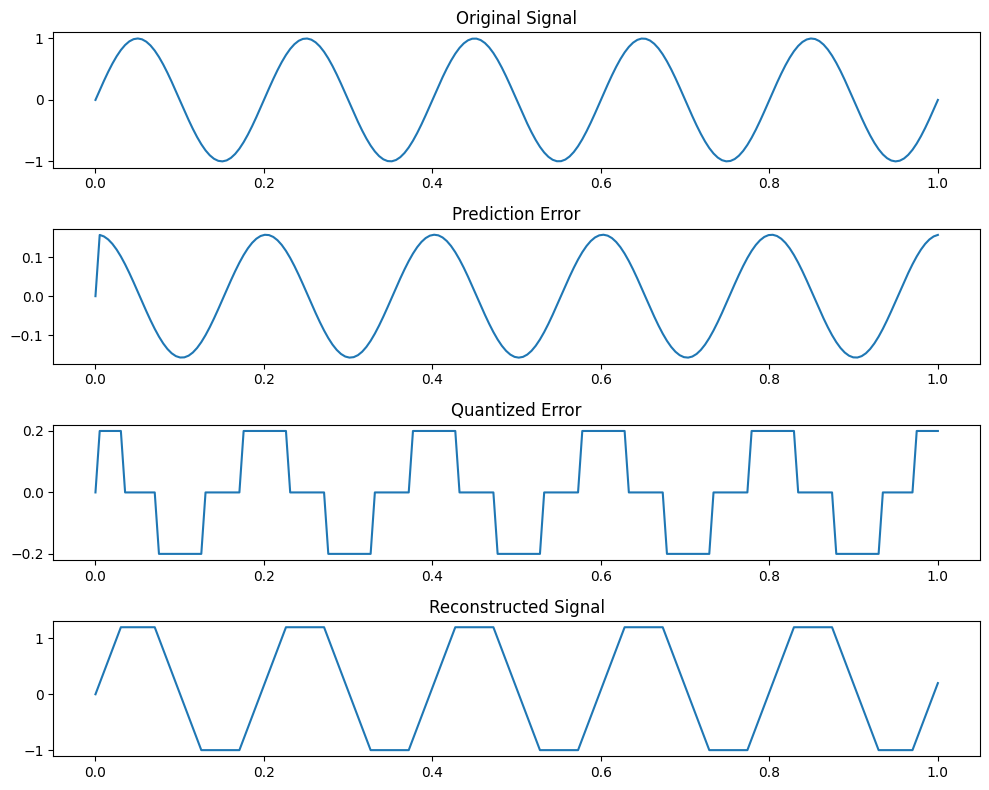

In [20]:
#Perform the DPCM modulation and demodulation using MATLAB/ Python.
import numpy as np
import matplotlib.pyplot as plt

# Generate signal
t = np.linspace(0, 1, 200)
x = np.sin(2 * np.pi * 5 * t)

# Quantization step size
step_size = 0.2

# Initialize arrays
predicted = np.zeros_like(x)
error = np.zeros_like(x)
q_error = np.zeros_like(x)

# DPCM Encoding
for i in range(1, len(x)):
    predicted[i] = x[i - 1]
    error[i] = x[i] - predicted[i]
    q_error[i] = step_size * np.round(error[i] / step_size)

# DPCM Decoding (Reconstruction)
reconstructed = np.zeros_like(x)
for i in range(1, len(x)):
    reconstructed[i] = reconstructed[i - 1] + q_error[i]

# Plotting
plt.figure(figsize=(10, 8))

# Original signal
plt.subplot(4, 1, 1)
plt.plot(t, x)
plt.title("Original Signal")

# Prediction error
plt.subplot(4, 1, 2)
plt.plot(t, error)
plt.title("Prediction Error")

# Quantized error
plt.subplot(4, 1, 3)
plt.plot(t, q_error)
plt.title("Quantized Error")

# Reconstructed signal
plt.subplot(4, 1, 4)
plt.plot(t, reconstructed)
plt.title("Reconstructed Signal")

plt.tight_layout()
plt.show()

1. Theory: What is PAM?
🔹 Definition

PAM (Pulse Amplitude Modulation) is a modulation technique where:

The amplitude of pulses is varied according to the message signal.

🔹 Simple Idea
Binary 1 → high amplitude
Binary 0 → low (or negative) amplitude
🔹 Mathematical Representation

For binary PAM:

𝑠
(
𝑡
)
=
𝐴
⋅
𝑚
(
𝑡
)
s(t)=A⋅m(t)

Where:

𝐴
A = amplitude
𝑚
(
𝑡
)
m(t) = message (bits)
🔹 PAM Signal Visualization
4

👉 You can see:

Pulse height changes with bits
Time duration remains constant
✅ 2. Where It Fits in Digital Communication (DC)

📚 PAM belongs to:

👉 Baseband Digital Transmission

Flow:
Line Coding → PAM → PCM → ASK/FSK/PSK

👉 Also used as:

Intermediate step in PCM (Pulse Code Modulation)
✅ 3. Concept Explanation (Step-by-Step)
🔹 Step 1: Bit Generation

Random binary sequence:

0
,
1
,
1
,
0
,
1
,
.
.
.
0,1,1,0,1,...
🔹 Step 2: Mapping

Convert bits → amplitudes:

1 → +A
0 → -A

👉 This is called Polar PAM

🔹 Step 3: Pulse Shaping

Each bit is stretched over time:

Creates rectangular pulses
🔹 Step 4: Transmission + Noise

Signal passes through channel:

𝑟
(
𝑡
)
=
𝑠
(
𝑡
)
+
𝑛
(
𝑡
)
r(t)=s(t)+n(t)
🔹 Step 5: Sampling

Receiver samples at middle of each bit

🔹 Step 6: Decision Rule
If sample > 0 → 1
If sample < 0 → 0

💡 Viva Line:

“In PAM, information is transmitted by varying pulse amplitude while keeping time and width constant.”

✅ 4. Code Explanation (Line by Line)
🔹 Import Libraries
import numpy as np
import matplotlib.pyplot as plt
numpy → numerical operations
matplotlib → plotting
🔹 Parameters
num_bits = 20
samples_per_bit = 100
A = 5
num_bits → number of bits
samples_per_bit → resolution of each pulse
A → amplitude
🔹 Generate Random Bits
bits = np.random.randint(0, 2, num_bits)

👉 Creates binary data (0s and 1s)

🔹 Mapping (Important)
symbols = np.where(bits == 1, A, -A)

👉 Converts:

1 → +5
0 → -5

💡 This is Polar PAM

🔹 Generate PAM Signal
pam_signal = np.repeat(symbols, samples_per_bit)

👉 Each bit becomes a rectangular pulse

🔹 Time Axis
t = np.arange(len(pam_signal)) / samples_per_bit

👉 Creates time scale for plotting

🔹 Add Noise
noise = np.random.normal(0, 1, len(pam_signal))
received_signal = pam_signal + noise

👉 Simulates real channel:

Gaussian noise added
🔹 Sampling
sample_idx = np.arange(samples_per_bit // 2, len(received_signal), samples_per_bit)
samples = received_signal[sample_idx]

👉 Samples taken at:

Middle of each bit (best detection point)
🔹 Decision Making
recovered_bits = (samples > 0).astype(int)

👉 Rule:

Positive → 1
Negative → 0
🔹 Reconstruct Signal
demod_symbols = np.where(recovered_bits == 1, A, -A)
demod_signal = np.repeat(demod_symbols, samples_per_bit)

👉 Converts back to PAM waveform

✅ 5. Output Interpretation (VERY IMPORTANT)
4
🔹 1. Original Bits
Step signal (0 and 1)
🔹 2. PAM Signal
Rectangular pulses
Amplitude = ±A
🔹 3. Received Signal
Noisy version of PAM
Sampling points shown
🔹 4. Demodulated Signal
Reconstructed pulses
Should match original

💡 Viva Tip:

“If noise is small, recovered bits match original bits exactly.”

✅ 6. Important Viva Questions
🔸 Q1: What is PAM?

👉 Modulation where amplitude varies with message

🔸 Q2: Types of PAM?
Unipolar
Polar
Bipolar
🔸 Q3: Why sampling at middle?

👉 Minimum error due to noise

🔸 Q4: What is decision threshold?

👉 Zero (in this case)

🔸 Q5: Effect of noise?

👉 Can flip bits → errors

🔸 Q6: Advantage of PAM?

👉 Simple implementation

🔸 Q7: Disadvantage?

👉 Sensitive to noise

🔥 Final Exam Line (Must Remember)

“PAM transmits digital data by varying the amplitude of pulses, and the receiver recovers data by sampling and threshold detection.”

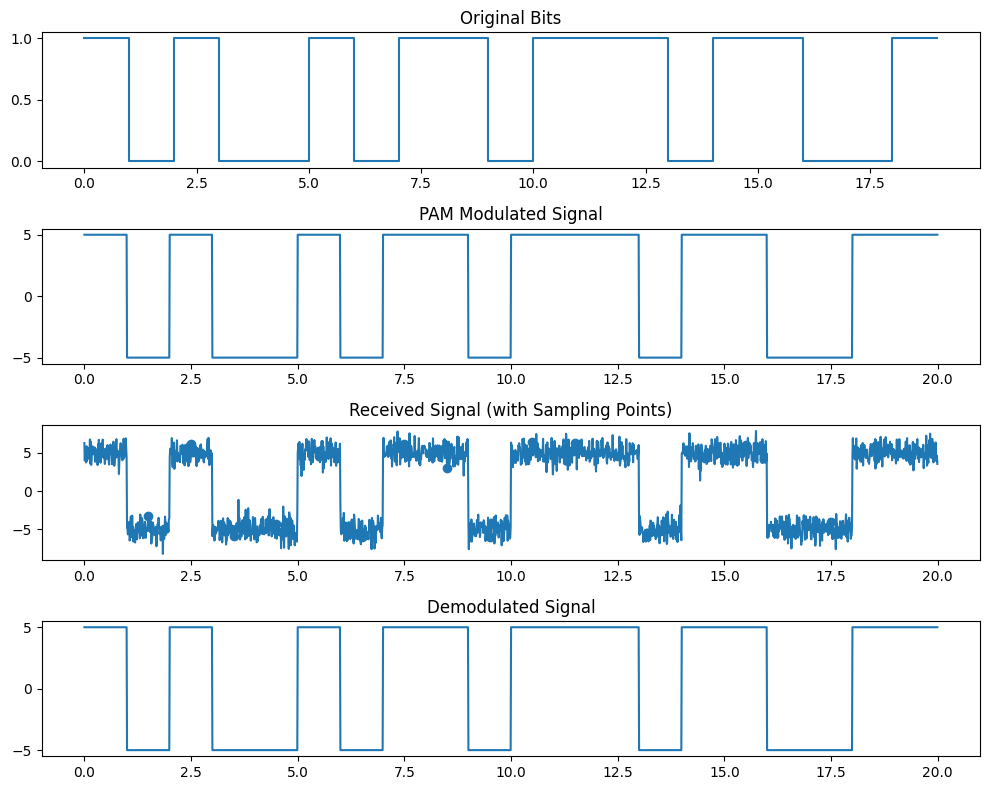

Original bits: [1 0 1 0 0 1 0 1 1 0 1 1 1 0 1 1 0 0 1 1]
Recovered bits: [1 0 1 0 0 1 0 1 1 0 1 1 1 0 1 1 0 0 1 1]


In [21]:
#Perform the PAM modulation and demodulation using MATLAB/ Python.
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_bits = 20
samples_per_bit = 100
A = 5

# Generate random bits
bits = np.random.randint(0, 2, num_bits)

# Map bits to symbols (+A, -A)
symbols = np.where(bits == 1, A, -A)

# Generate PAM signal
pam_signal = np.repeat(symbols, samples_per_bit)

# Time axis
t = np.arange(len(pam_signal)) / samples_per_bit

# Add noise
noise = np.random.normal(0, 1, len(pam_signal))
received_signal = pam_signal + noise

# Sampling (middle of each bit)
sample_idx = np.arange(samples_per_bit // 2, len(received_signal), samples_per_bit)
samples = received_signal[sample_idx]

# Decision making
recovered_bits = (samples > 0).astype(int)

# Reconstruct signal
demod_symbols = np.where(recovered_bits == 1, A, -A)
demod_signal = np.repeat(demod_symbols, samples_per_bit)

# Plotting
plt.figure(figsize=(10, 8))

# Original bits
plt.subplot(4, 1, 1)
plt.step(range(len(bits)), bits, where='post')
plt.title("Original Bits")

# PAM signal
plt.subplot(4, 1, 2)
plt.plot(t, pam_signal)
plt.title("PAM Modulated Signal")

# Received signal with sampling points
plt.subplot(4, 1, 3)
plt.plot(t, received_signal)
plt.scatter(sample_idx / samples_per_bit, samples)
plt.title("Received Signal (with Sampling Points)")

# Demodulated signal
plt.subplot(4, 1, 4)
plt.plot(t, demod_signal)
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

# Print results
print("Original bits:", bits)
print("Recovered bits:", recovered_bits)